# Lab 7- Data Analysis


## Exercise 1: Reading

### HiggsML
In 2014, some of my colleagues from the ATLAS experiment put together a Higgs Machine Learning Challenge, which was hosted on [Kaggle](https://www.kaggle.com). Please read sections 1 and 3 (skip/skim 2) of [The HiggsML Technical Documentation](https://higgsml.lal.in2p3.fr/files/2014/04/documentation_v1.8.pdf). 

Kaggle is a platform for data science competitions, with cash awards for winners. Kaggle currently hosts over 50,000 public datasets and associated competitions. Later in the course we will look at a variety of problems hosted on Kaggle and similar platforms. 

### SUSY Dataset

For the next few labs we will use datasets used in the [first paper on Deep Learning in High Energy physics](https://arxiv.org/pdf/1402.4735.pdf). Please read up to the "Deep Learning" section (end of page 5). This paper demonstrates that Deep Neural Networks can learn from raw data the features that are typically used by physicists for searches for exotics particles. The authors provide the data they used for this paper. They considered two benchmark scenarios: Higgs and SUSY.

## Exercise 2: Download SUSY Dataset

The information about the dataset can be found at the [UCI Machine Learning Repository](https://archive.ics.uci.edu/ml/index.php). We'll start with the [SUSY Dataset](https://archive.ics.uci.edu/ml/datasets/SUSY). 

### Download
In a terminal, download the data directly from the source and then decompress it. For example:

* To download:
    * On Mac OS: 
    `curl http://archive.ics.uci.edu/ml/machine-learning-databases/00279/SUSY.csv.gz > SUSY.csv.gz`

    * In linux:
    `wget http://archive.ics.uci.edu/ml/machine-learning-databases/00279/SUSY.csv.gz`

* To uncompress:
`gunzip SUSY.csv.gz`

In [3]:
#!curl http://archive.ics.uci.edu/ml/machine-learning-databases/00279/SUSY.csv.gz > SUSY.csv.gz

!curl "http://archive.ics.uci.edu/ml/machine-learning-databases/00279/SUSY.csv.gz" -o SUSY.csv.gz

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100   157  100   157    0     0    235      0 --:--:-- --:--:-- --:--:--   235


In [4]:
#!rm SUSY.csv


In [5]:
#!gunzip SUSY.csv.gz

!ls -lh


total 2.5G
-rwxrwxrwx 1 mahim mahim  56K Feb  6 23:46 'Git Hub Setup Guide (wsl & Mac Os).pdf'
drwxrwxrwx 1 mahim mahim 4.0K Feb  6 23:45  Lab.2
drwxrwxrwx 1 mahim mahim 4.0K Feb 16 23:41  Lab.3
drwxrwxrwx 1 mahim mahim 4.0K Feb  6 13:33  Lab.4
-rwxrwxrwx 1 mahim mahim  51K Mar  1 22:28  Lab.4.solution.ipynb
-rwxrwxrwx 1 mahim mahim  15K Mar  2 17:46  Lab.5.solution.ipynb
-rwxrwxrwx 1 mahim mahim  33K Mar 27 19:03  Lab.6.blackjackgame.uml.drawio.pdf
-rwxrwxrwx 1 mahim mahim 108K Mar 27 19:12  Lab.6.solution.ipynb
-rwxrwxrwx 1 mahim mahim 4.8M Apr 10 18:47  Lab.7.solution.ipynb
drwxrwxrwx 1 mahim mahim 4.0K Feb  6 13:33  Labs.3
drwxrwxrwx 1 mahim mahim 4.0K Mar 27 19:16 'New folder'
-rwxrwxrwx 1 mahim mahim 228M Mar 29 22:06  SUSY-small.csv
-rwxrwxrwx 1 mahim mahim 2.3G Mar 29 21:56  SUSY.csv
-rwxrwxrwx 1 mahim mahim  157 Apr 10 19:19  SUSY.csv.gz
-rwxrwxrwx 1 mahim mahim   14 Mar  1 21:53  Test.foo
drwxrwxrwx 1 mahim mahim 4.0K Mar  1 22:08  __pycache__
-rwxrwxrwx 1 mahim mahim   80 Ma

The data is provided as a comma separated file.

In [6]:
filename="SUSY-small.csv"
# print out the first 5 lines using unix head command
!head -5  "SUSY.csv"

0.000000000000000000e+00,9.728614687919616699e-01,6.538545489311218262e-01,1.176224589347839355e+00,1.157156467437744141e+00,-1.739873170852661133e+00,-8.743090629577636719e-01,5.677649974822998047e-01,-1.750000417232513428e-01,8.100607395172119141e-01,-2.525521218776702881e-01,1.921887040138244629e+00,8.896374106407165527e-01,4.107718467712402344e-01,1.145620822906494141e+00,1.932632088661193848e+00,9.944640994071960449e-01,1.367815494537353516e+00,4.071449860930442810e-02
1.000000000000000000e+00,1.667973041534423828e+00,6.419061869382858276e-02,-1.225171446800231934e+00,5.061022043228149414e-01,-3.389389812946319580e-01,1.672542810440063477e+00,3.475464344024658203e+00,-1.219136357307434082e+00,1.295456290245056152e-02,3.775173664093017578e+00,1.045977115631103516e+00,5.680512785911560059e-01,4.819284379482269287e-01,0.000000000000000000e+00,4.484102725982666016e-01,2.053557634353637695e-01,1.321893453598022461e+00,3.775840103626251221e-01
1.000000000000000000e+00,4.4483992457389831

## Reducing the dataset

This is a rather large dataset. If you have trouble loading it, we can easily make a new file with less data.

Here we look at the size of the data

In [7]:
!ls -lh

total 2.5G
-rwxrwxrwx 1 mahim mahim  56K Feb  6 23:46 'Git Hub Setup Guide (wsl & Mac Os).pdf'
drwxrwxrwx 1 mahim mahim 4.0K Feb  6 23:45  Lab.2
drwxrwxrwx 1 mahim mahim 4.0K Feb 16 23:41  Lab.3
drwxrwxrwx 1 mahim mahim 4.0K Feb  6 13:33  Lab.4
-rwxrwxrwx 1 mahim mahim  51K Mar  1 22:28  Lab.4.solution.ipynb
-rwxrwxrwx 1 mahim mahim  15K Mar  2 17:46  Lab.5.solution.ipynb
-rwxrwxrwx 1 mahim mahim  33K Mar 27 19:03  Lab.6.blackjackgame.uml.drawio.pdf
-rwxrwxrwx 1 mahim mahim 108K Mar 27 19:12  Lab.6.solution.ipynb
-rwxrwxrwx 1 mahim mahim 4.8M Apr 10 19:19  Lab.7.solution.ipynb
drwxrwxrwx 1 mahim mahim 4.0K Feb  6 13:33  Labs.3
drwxrwxrwx 1 mahim mahim 4.0K Mar 27 19:16 'New folder'
-rwxrwxrwx 1 mahim mahim 228M Mar 29 22:06  SUSY-small.csv
-rwxrwxrwx 1 mahim mahim 2.3G Mar 29 21:56  SUSY.csv
-rwxrwxrwx 1 mahim mahim  157 Apr 10 19:19  SUSY.csv.gz
-rwxrwxrwx 1 mahim mahim   14 Mar  1 21:53  Test.foo
drwxrwxrwx 1 mahim mahim 4.0K Mar  1 22:08  __pycache__
-rwxrwxrwx 1 mahim mahim   80 Ma

We see that we have 5 million datapoints.

In [8]:
!wc -l SUSY.csv

5000000 SUSY.csv


We create a new file of the first half million. This is sufficient for our needs in this lab:

In [9]:
!head -500000 SUSY.csv > SUSY-small.csv

In [10]:
ls -lh

total 5152448
-rw-------@ 1 afarbin  staff   389K Mar 20 13:49 Lab.7.ipynb
-rw-r--r--@ 1 afarbin  staff   8.0M Mar 20 12:18 Lab.7.pdf
-rw-r--r--  1 afarbin  staff   228M Mar 20 13:50 SUSY-small.csv
-rw-r--r--@ 1 afarbin  staff   2.2G Mar 20 11:36 SUSY.csv


In [10]:
! wc -l SUSY-small.csv

500000 SUSY-small.csv


Use this file for the rest of the lab to make this run faster.

### First Look

Each row represents a LHC collision event. Each column contains some observable from that event. The variable names are ([based on documentation](https://archive.ics.uci.edu/ml/datasets/SUSY)):

In [11]:
VarNames=["signal", "l_1_pT", "l_1_eta","l_1_phi", "l_2_pT", "l_2_eta", "l_2_phi", "MET", "MET_phi", "MET_rel", "axial_MET", "M_R", "M_TR_2", "R", "MT2", "S_R", "M_Delta_R", "dPhi_r_b", "cos_theta_r1"]

Some of these variables represent the "raw" kinematics of the observed final state particles, while others are "features" that are derived from these raw quantities:

In [12]:
RawNames=["l_1_pT", "l_1_eta","l_1_phi", "l_2_pT", "l_2_eta", "l_2_phi", "MET", "MET_phi"]
FeatureNames=list(set(VarNames[1:]).difference(RawNames))

In [13]:
RawNames

['l_1_pT',
 'l_1_eta',
 'l_1_phi',
 'l_2_pT',
 'l_2_eta',
 'l_2_phi',
 'MET',
 'MET_phi']

In [14]:
FeatureNames

['axial_MET',
 'M_Delta_R',
 'M_TR_2',
 'cos_theta_r1',
 'dPhi_r_b',
 'R',
 'MT2',
 'M_R',
 'S_R',
 'MET_rel']

We will use pandas to read in the file, and matplotlib to make plots. The following ensures pandas is installed and sets everything up:

In [15]:
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

Now we can read the data into a pandas dataframe:

In [16]:
filename = "SUSY.csv"
df = pd.read_csv(filename, dtype='float64', names=VarNames)

You can see the data in Jupyter by just evaluateing the dataframe:

In [17]:
df

,signal,l_1_pT,l_1_eta,l_1_phi,l_2_pT,l_2_eta,l_2_phi,MET,MET_phi,MET_rel,axial_MET,M_R,M_TR_2,R,MT2,S_R,M_Delta_R,dPhi_r_b,cos_theta_r1
0,0.0,0.972861,0.653855,1.176225,1.157156,-1.739873,-0.874309,0.567765,-0.175000,0.810061,-0.252552,1.921887,0.889637,0.410772,1.145621,1.932632,0.994464,1.367815,0.040714
1,1.0,1.667973,0.064191,-1.225171,0.506102,-0.338939,1.672543,3.475464,-1.219136,0.012955,3.775174,1.045977,0.568051,0.481928,0.000000,0.448410,0.205356,1.321893,0.377584
2,1.0,0.444840,-0.134298,-0.709972,0.451719,-1.613871,-0.768661,1.219918,0.504026,1.831248,-0.431385,0.526283,0.941514,1.587535,2.024308,0.603498,1.562374,1.135454,0.180910
3,1.0,0.381256,-0.976145,0.693152,0.448959,0.891753,-0.677328,2.033060,1.533041,3.046260,-1.005285,0.569386,1.015211,1.582217,1.551914,0.761215,1.715464,1.492257,0.090719
4,1.0,1.309996,-0.690089,-0.676259,1.589283,-0.693326,0.622907,1.087562,-0.381742,0.589204,1.365479,1.179295,0.968218,0.728563,0.000000,1.083158,0.043429,1.154854,0.094859
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4999995,1.0,0.853325,-0.961783,-1.487277,0.678190,0.493580,1.647969,1.843867,0.276954,1.025105,-1.486535,0.892879,1.684429,1.674084,3.366298,1.046707,2.646649,1.389226,0.364599
4999996,0.0,0.951581,0.139370,1.436884,0.880440,-0.351948,-0.740852,0.290863,-0.732360,0.001360,0.257738,0.802871,0.545319,0.602730,0.002998,0.748959,0.401166,0.443471,0.239953
4999997,0.0,0.840389,1.419162,-1.218766,1.195631,1.695645,0.663756,0.490888,-0.509186,0.704289,0.045744,0.825015,0.723530,0.778236,0.752942,0.838953,0.614048,1.210595,0.026692
4999998,1.0,1.784218,-0.833565,-0.560091,0.953342,-0.688969,-1.428233,2.660703,-0.861344,2.116892,2.906151,1.232334,0.952444,0.685846,0.000000,0.781874,0.676003,1.197807,0.093689


The first column stores the "truth" label of whether an event was signal or not. Pandas makes it easy to create dataframes that store only the signal or background events:

In [19]:
df_sig=df[df.signal==1]
df_bkg=df[df.signal==0]

The following example plots the signal and background distributions of every variable. Note that we use VarNames[1:] to skip the first variable, which was the true label.

l_1_pT


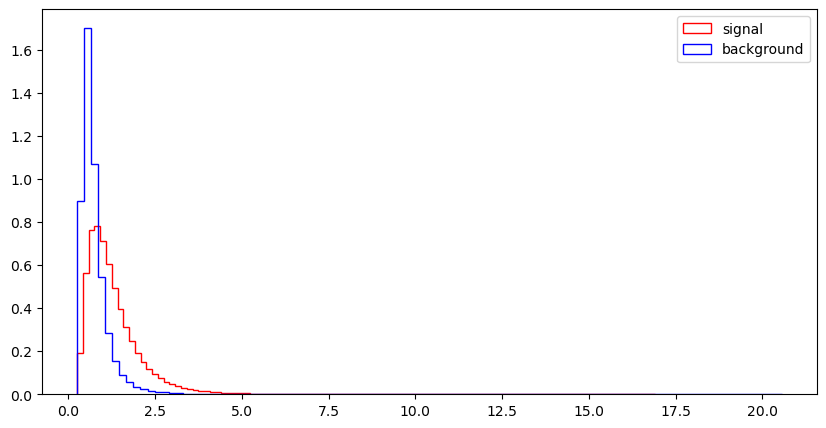

l_1_eta


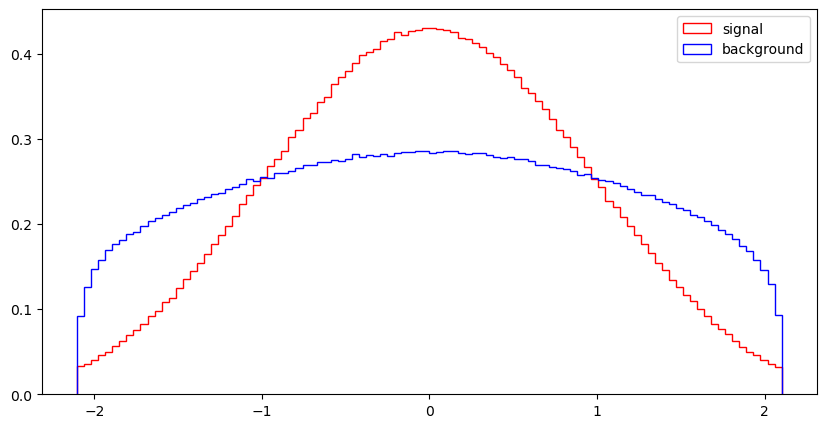

l_1_phi


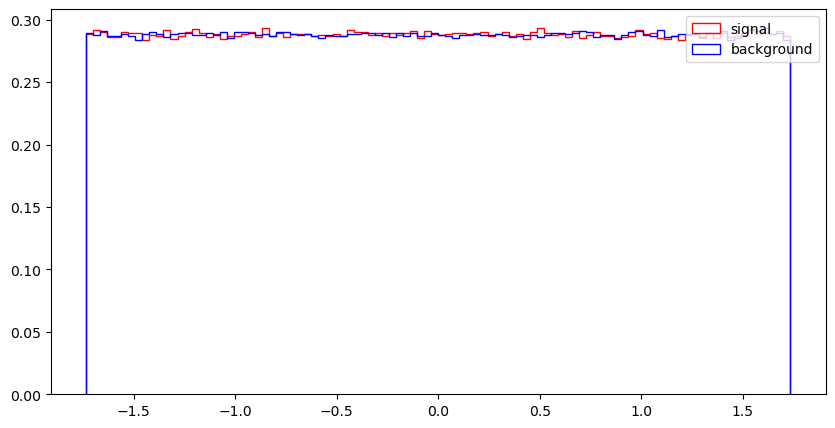

l_2_pT


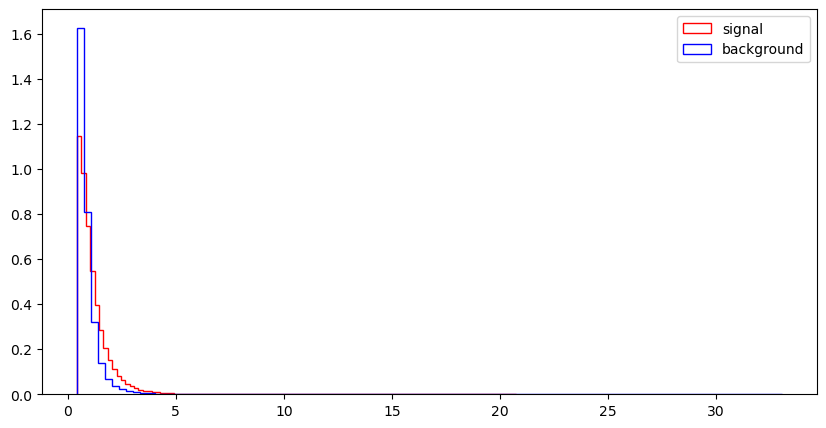

l_2_eta


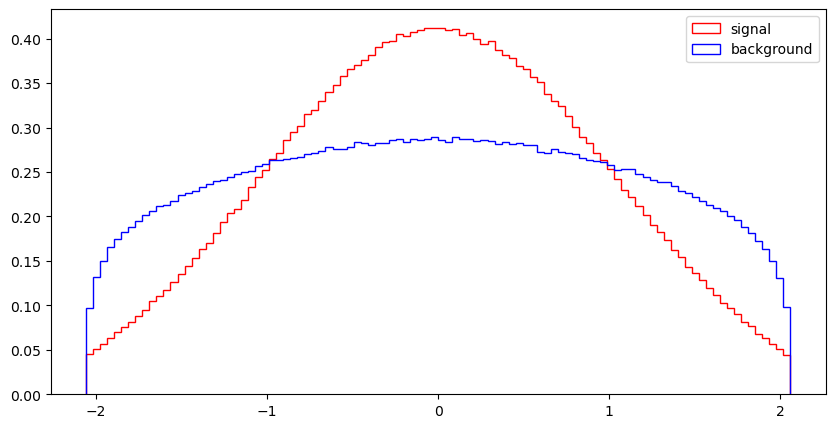

l_2_phi


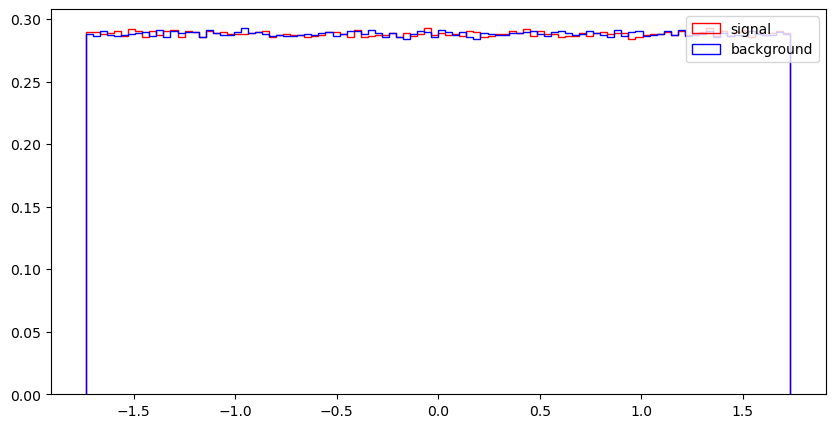

MET


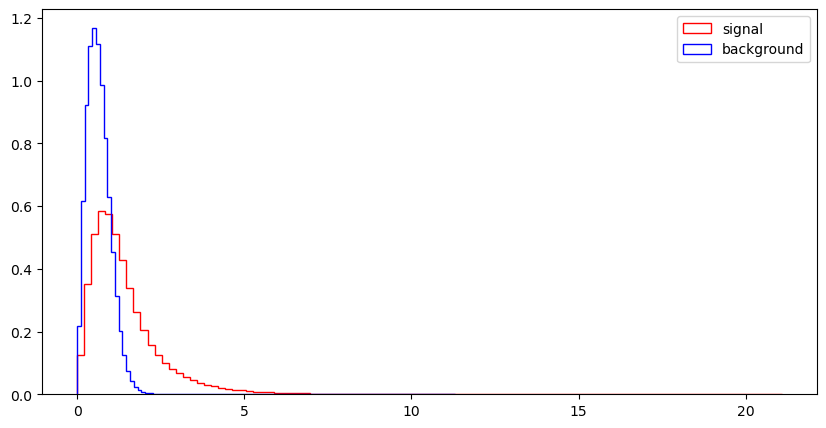

MET_phi


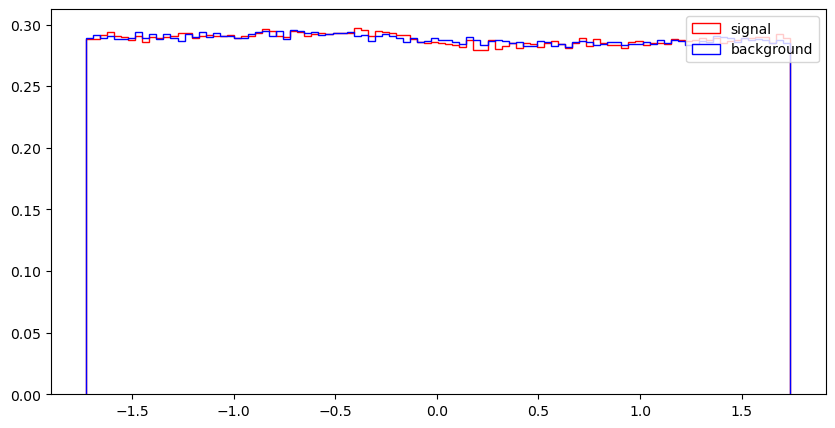

MET_rel


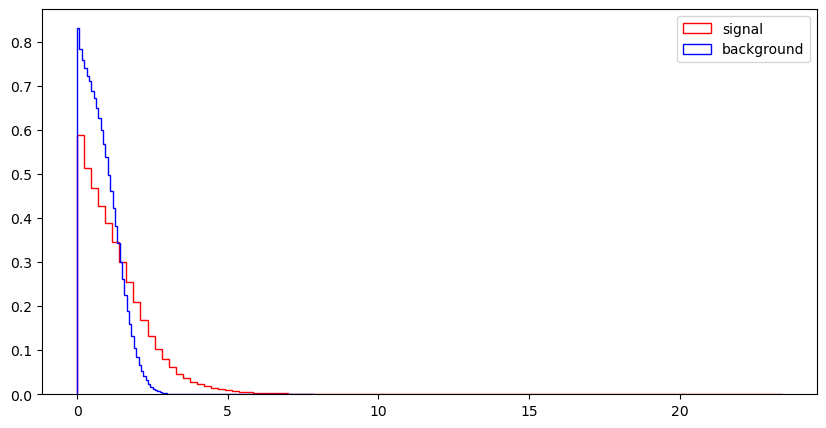

axial_MET


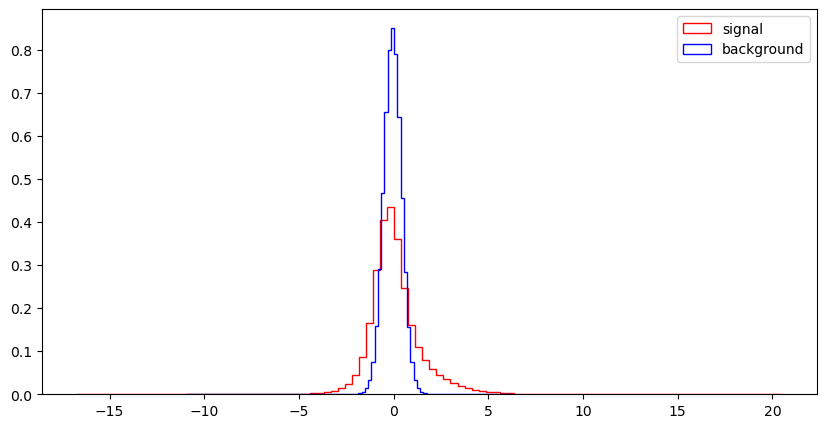

M_R


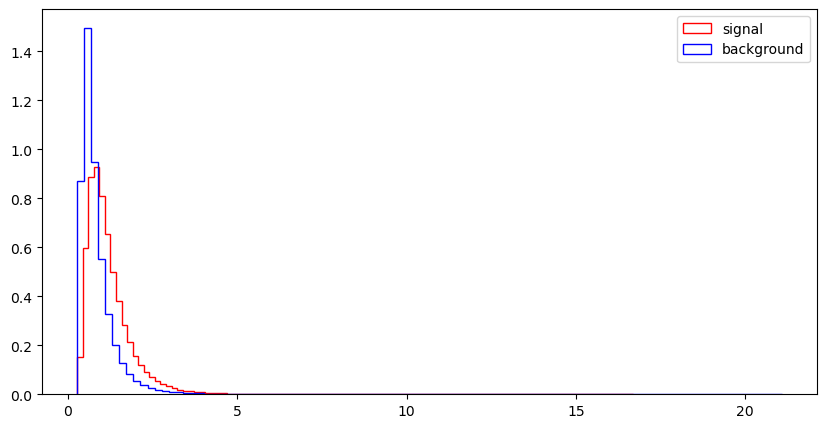

M_TR_2


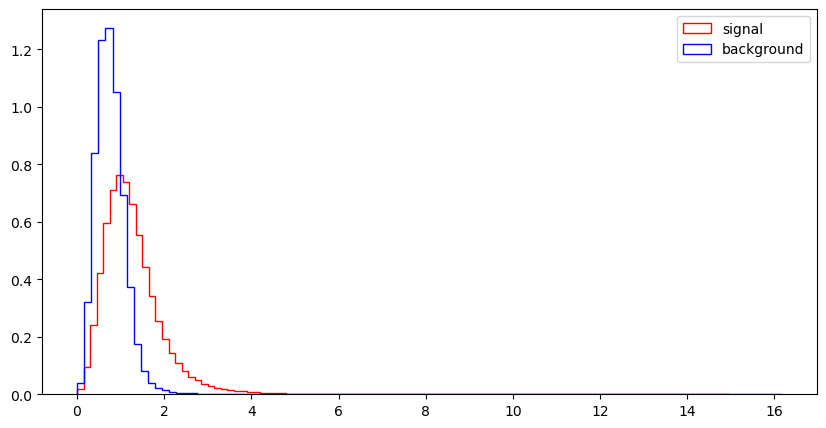

R


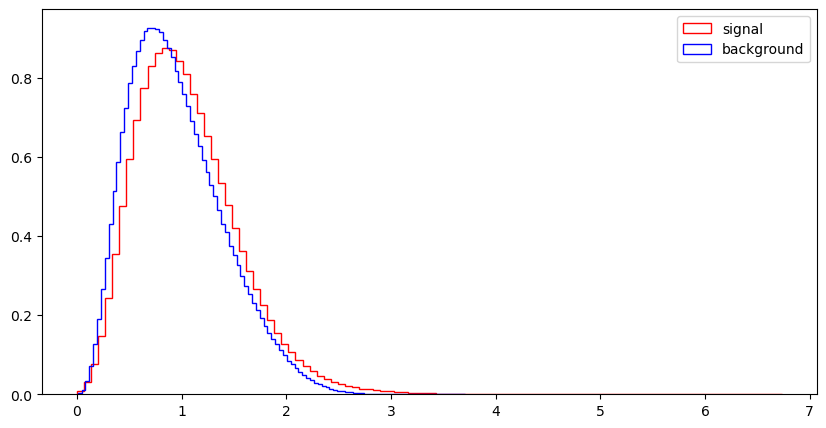

MT2


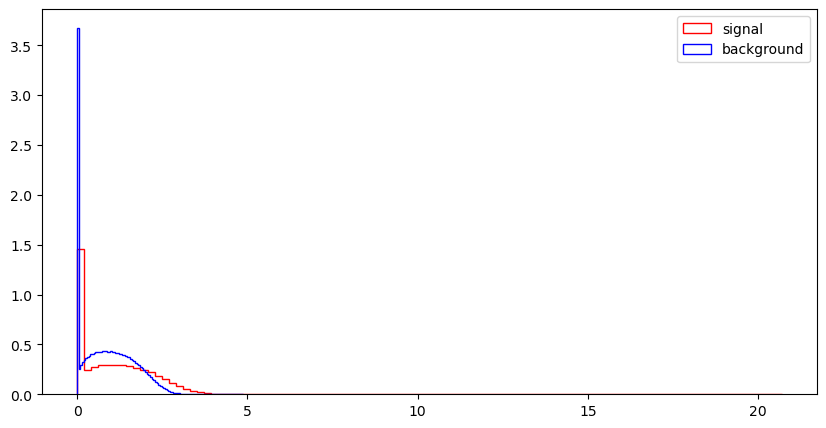

S_R


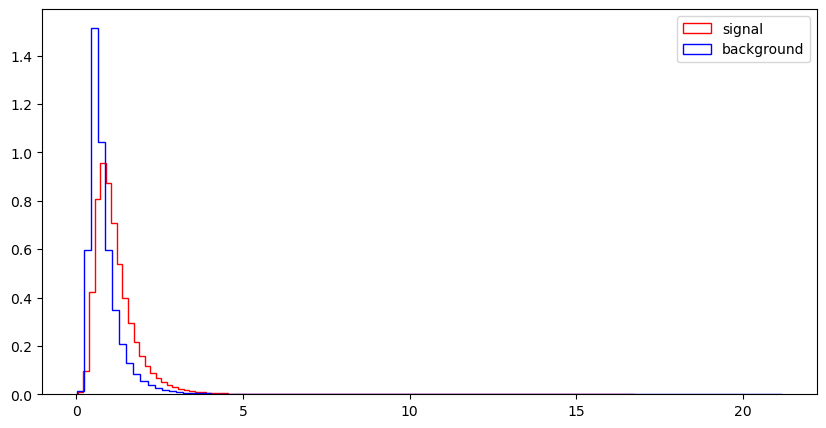

M_Delta_R


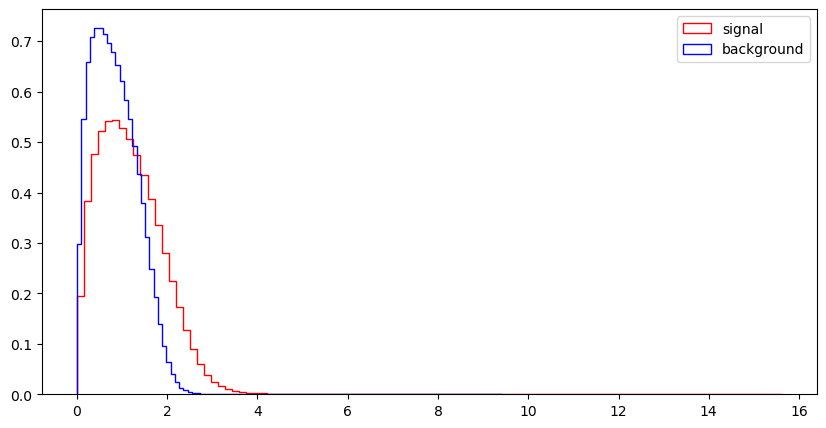

dPhi_r_b


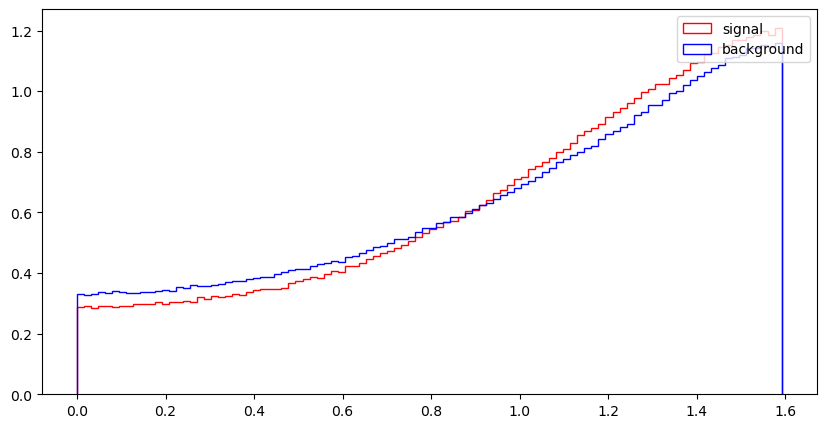

cos_theta_r1


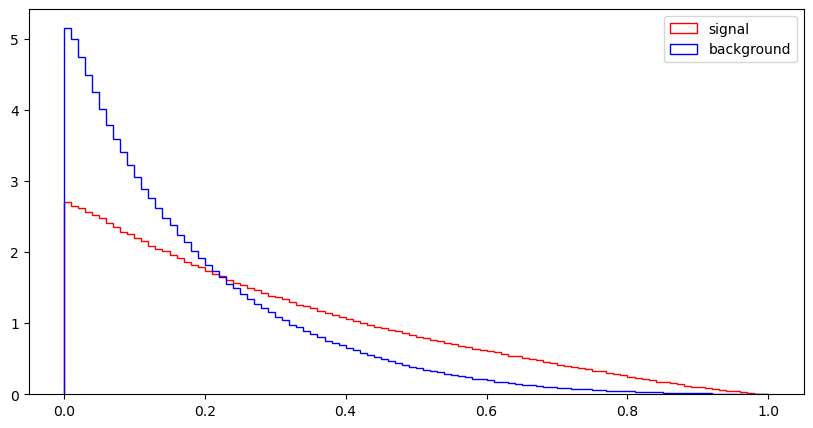

In [20]:
import numpy as np
for var in VarNames[1:]:
    print (var)
    plt.figure(figsize=(10,5))
    plt.hist(np.array(df_sig[var]),bins=100,histtype="step", color="red",label="signal",density=1, stacked=True)
    plt.hist(np.array(df_bkg[var]),bins=100,histtype="step", color="blue", label="background",density=1, stacked=True)
    plt.legend(loc='upper right')
    plt.show()

## Exercise 3: Make nice figures

Now use `matplotlib` to reproduce as closely as you can figures 5 and 6 from the paper. This exercise is intended to get you to familiarize yourself with making nicely formatted `matplotlib` figures with multiple plots. Note that the plots in the paper are actually wrong!

## Exercise 4: Correlation

### Exercise 4.1

#### Part a
Write a function that creates pair plots and use it to compare variables in the SUSY sample, separately for low and high-level features. Refer to Lecture 13 for details. Do not use `seaborn`.

#### Part b
Making these plots can be slow because creating each plot initiates a full loop over the data. Make at least one modification to your function in part a to speed it up. Can you propose a different method of creating histograms that would speed up making such pair plots?

#### Part c
Which observables appear to be best for separating signal from background?

### Exercise 4.2

#### Part a
Install [tabulate](https://github.com/astanin/python-tabulate). 

#### Part b
Use numpy to compute the [covariance matrix](https://numpy.org/doc/stable/reference/generated/numpy.cov.html) and [correlation matrix](https://numpy.org/doc/stable/reference/generated/numpy.corrcoef.html) between all observabes, and separately between low and high-level features.

#### Part c
Use tabulate to create a well formatted table of the covariance and correlation matrices, with nice headings and appropriate significant figures. Embed the table into this notebook.

#### Part d
Write a function that takes a dataset and appropriate arguments and performs steps b and c.  

Hint: Example code for embedding a `tabulate` table into a notebook:

In [21]:
from IPython.display import HTML, display
import tabulate
table = [["A",1,2],
        ["C",3,4],
        ["D",5,6]]
display(HTML(tabulate.tabulate(table, tablefmt='html', headers=["X","Y","Z"])))

X,Y,Z
A,1,2
C,3,4
D,5,6


## Exercise 5: Selection

### Exercise 5.1

Part a
By looking at the signal/background distributions for each observable (e.g. $x$) determine which selection criteria would be optimal: 

1. $x > x_c$
2. $x < x_c$
3. $|x - \mu| > x_c$
4. $|x - \mu| < x_c$

where $x_c$ is value to be determined below.

### Exercise 5.2

Plot the True Positive Rate (TPR) (aka signal efficiency $\epsilon_S(x_c)$) and False Positive Rate (FPR) (aka background efficiency $\epsilon_B(x_c)$) as function of $x_c$ for applying the strategy in part a to each observable. 

### Exercise 5.3
Assume 3 different scenarios corresponding to different numbers of signal and background events expected in data:

1. Expect $N_S=10$, $N_B=100$.
1. Expect $N_S=100$, $N_B=1000$.
1. Expect $N_S=1000$, $N_B=10000$.
1. Expect $N_S=10000$, $N_B=100000$.

Plot the significance ($\sigma_{S'}$) for each observable as function of $x_c$ for each scenario, where 

$\sigma_{S'}= \frac{N'_S}{\sqrt{N'_S+N'_B}}$

and $N'_{S,B} = \epsilon_{S,B}(x_c) * N_{S,B}$.

## Exercise 6: Cut Flow


### Exercise 6.1

For each above scenario, choose a subset (minumum 3) of observables to use for selections, and values of $x_c$ based on your significance plots (part 3c). 

### Exercise 6.2
Create a "cut-flow" table for each scenario where you successively make the selections on each observable and tabulate $\epsilon_S$, $\epsilon_B$, $N'_S$, $N'_B$, and $\sigma_{S'}$.

### Exercise 6.3
In 3c above you computed the significance for each observable assuming to make no other selections on any other observable. If the variables are correlated, then this assumption can lead to non-optimial results when selecting on multiple variables. By looking at the correlation matrices and your answers to 4b, identify where this effect could be most detrimental to the significance. Attempt to correct the issue by applying the selection in one observable and then optimizing (part 3c) for a second observable. What happens if you change the order of your selection (make selection on second and optimize on first)?




## Exercise 7: ROC Curves

### Exercise 7.1
For the top 3 observables you identified earlier, create one figure overlaying the Reciever Operating Characteristic (ROC) curves for the 3 observables. Compute the area under the curves and report it in the legend of the figure.

### Exercise 7.2
Write a function that you can use to quickly create the figure in part a with other observables and different conditions. Note that you will likely revise this function as you do the remainder of the lab.

### Exercise 7.3
Use the function from part b to compare the ROC curves for the successive selections in lab 3, exercise 4. Specifically, plot the ROC curve after each selection.

### Exercise 7.4
Use your function and appropriate example to demonstrate the effect (if any) of changing order of the successive selections.



## Exercise 8: Linear Discriminant

### Exercise 8.1

Using numpy, compute the between-class $\bf{S}_B$ and within-class $\bf{S}_W$ covariance matrices defined as:

$$
\bf{S}_B = (\bf{m_2}-\bf{m_1})(\bf{m_2}-\bf{m_1})^T \\
$$
$$
\bf{S}_W = \sum_{i=1,2} \sum_{n=1}^{l_i} (\bf{x}_n^i - \bf{m}_i) (\bf{x}_n^i - \bf{m}_i)^T
$$

where $\bf{m_i}$ are the vectors containing the means for category 1 and 2, here defined as signal and background. Here $\bf{x}_n^i$ is the vector containing the observables for the $n$th example event in category $i$.

### Exercise 8.1

Compute the linear coefficients $\bf{w} = \bf{S_W}^{-1}(\bf{m_2}-\bf{m_1})$. Compare the histogram of the distribution of $F_n^i=\bf{w}^T\bf{x}_n^i$ for the two categories.

### Exercise 8.1

Draw the ROC curve for $F_n$. 

### Exercise 8.1

What is the maximal significance you can obtain in the scenarios in exercise 5? 

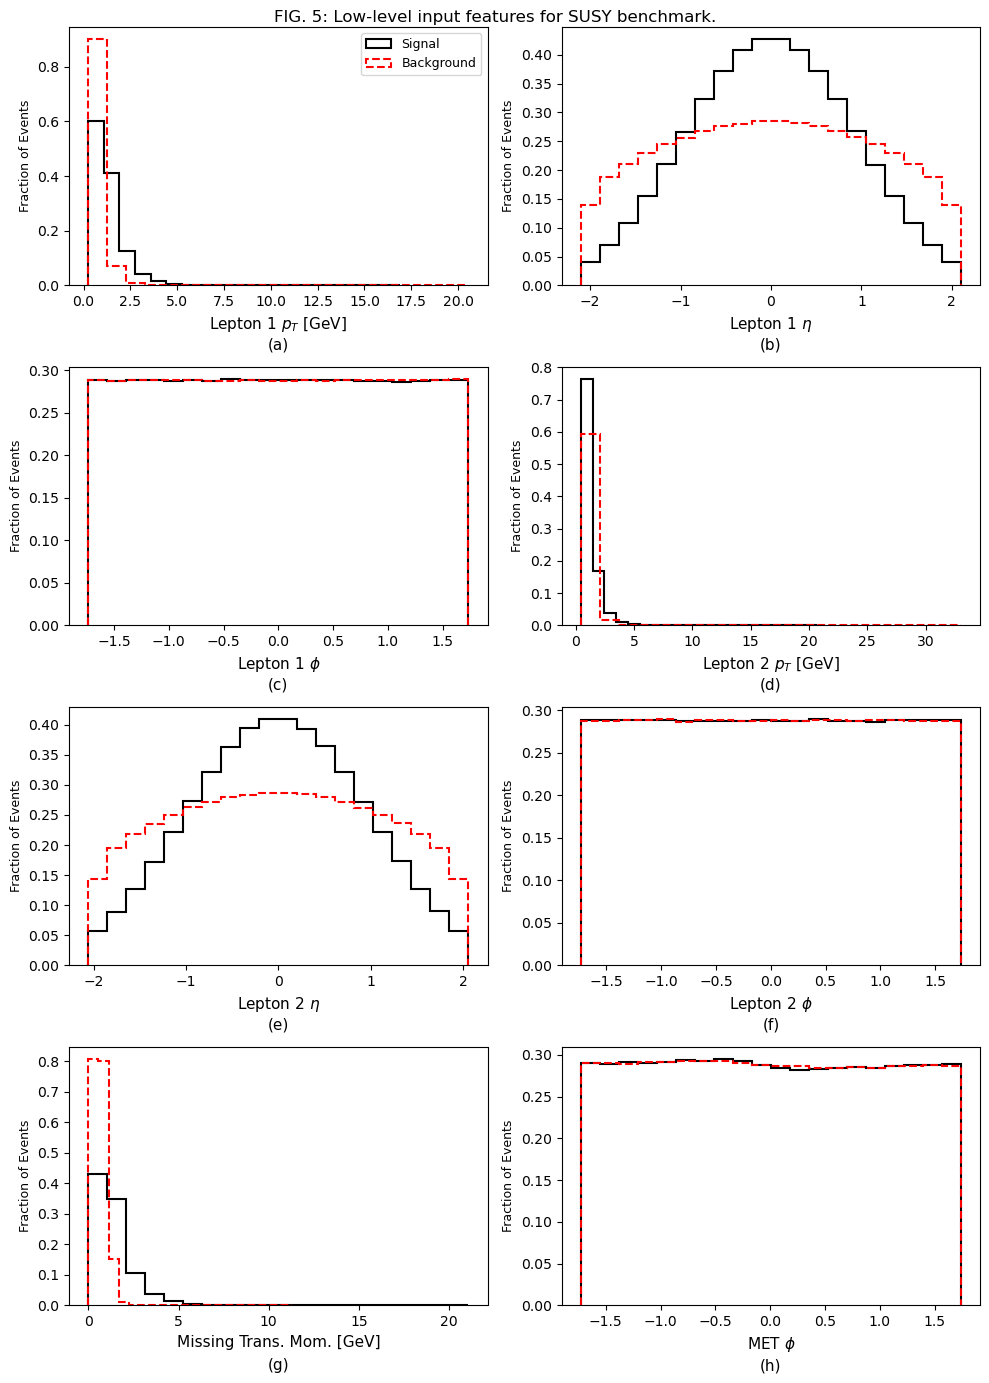

In [13]:
# 3

import numpy as np
import matplotlib.pyplot as plt

RawNames = ["l_1_pT", "l_1_eta", "l_1_phi", "l_2_pT", "l_2_eta", "l_2_phi", "MET", "MET_phi"]
fig5_labels = {
    "l_1_pT":   "Lepton 1 $p_T$ [GeV]",
    "l_2_pT":   "Lepton 2 $p_T$ [GeV]",
    "l_1_eta":  "Lepton 1 $\\eta$",
    "l_2_eta":  "Lepton 2 $\\eta$",
    "MET":      "Missing Trans. Mom. [GeV]",
    "MET_phi":  "MET $\\phi$",
    "l_1_phi":  "Lepton 1 $\\phi$",
    "l_2_phi":  "Lepton 2 $\\phi$",
}
sublabels = ["(a)","(b)","(c)","(d)","(e)","(f)","(g)","(h)"]

fig, axes = plt.subplots(4, 2, figsize=(10, 14))
axes = axes.flatten()

for i, var in enumerate(RawNames):
    ax = axes[i]
    ax.hist(np.array(df_sig[var]), bins=20, density=True, histtype='step',
            color='black', linewidth=1.5, label='Signal')
    ax.hist(np.array(df_bkg[var]), bins=20, density=True, histtype='step',
            color='red', linestyle='dashed', linewidth=1.5, label='Background')
    ax.set_xlabel(fig5_labels[var], fontsize=11)
    ax.set_ylabel("Fraction of Events", fontsize=9)
    ax.text(0.5, -0.25, sublabels[i], transform=ax.transAxes, ha='center', fontsize=11)
    if i == 0:
        ax.legend(fontsize=9)

plt.suptitle("FIG. 5: Low-level input features for SUSY benchmark.", fontsize=12)
plt.tight_layout()
plt.show()

# Used Claude to understand the photo, generate a code and explain to me why it used the paritcular code, and relied on this as a sample to understand the later exercises.

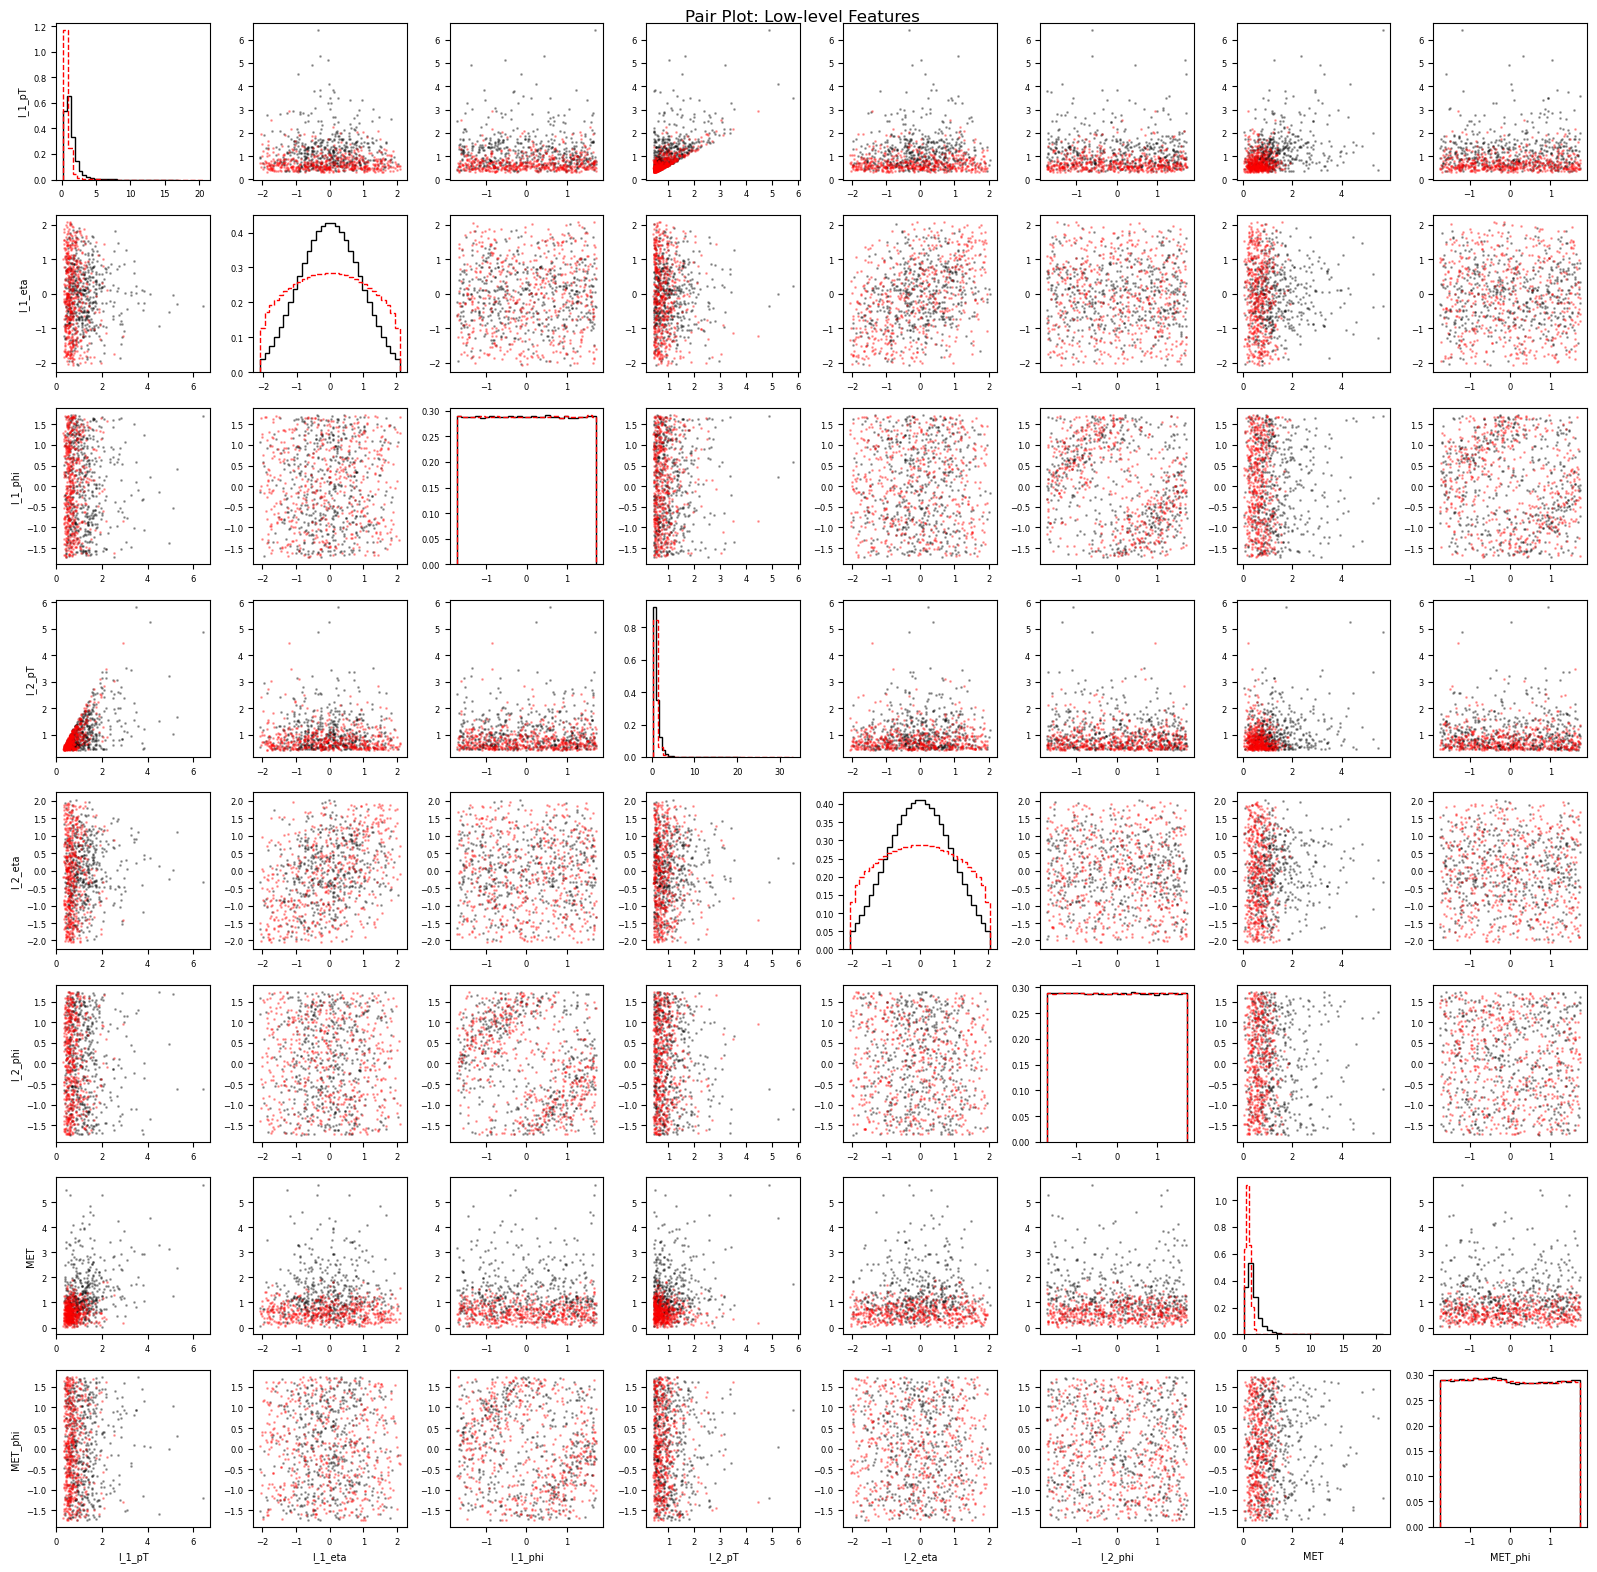

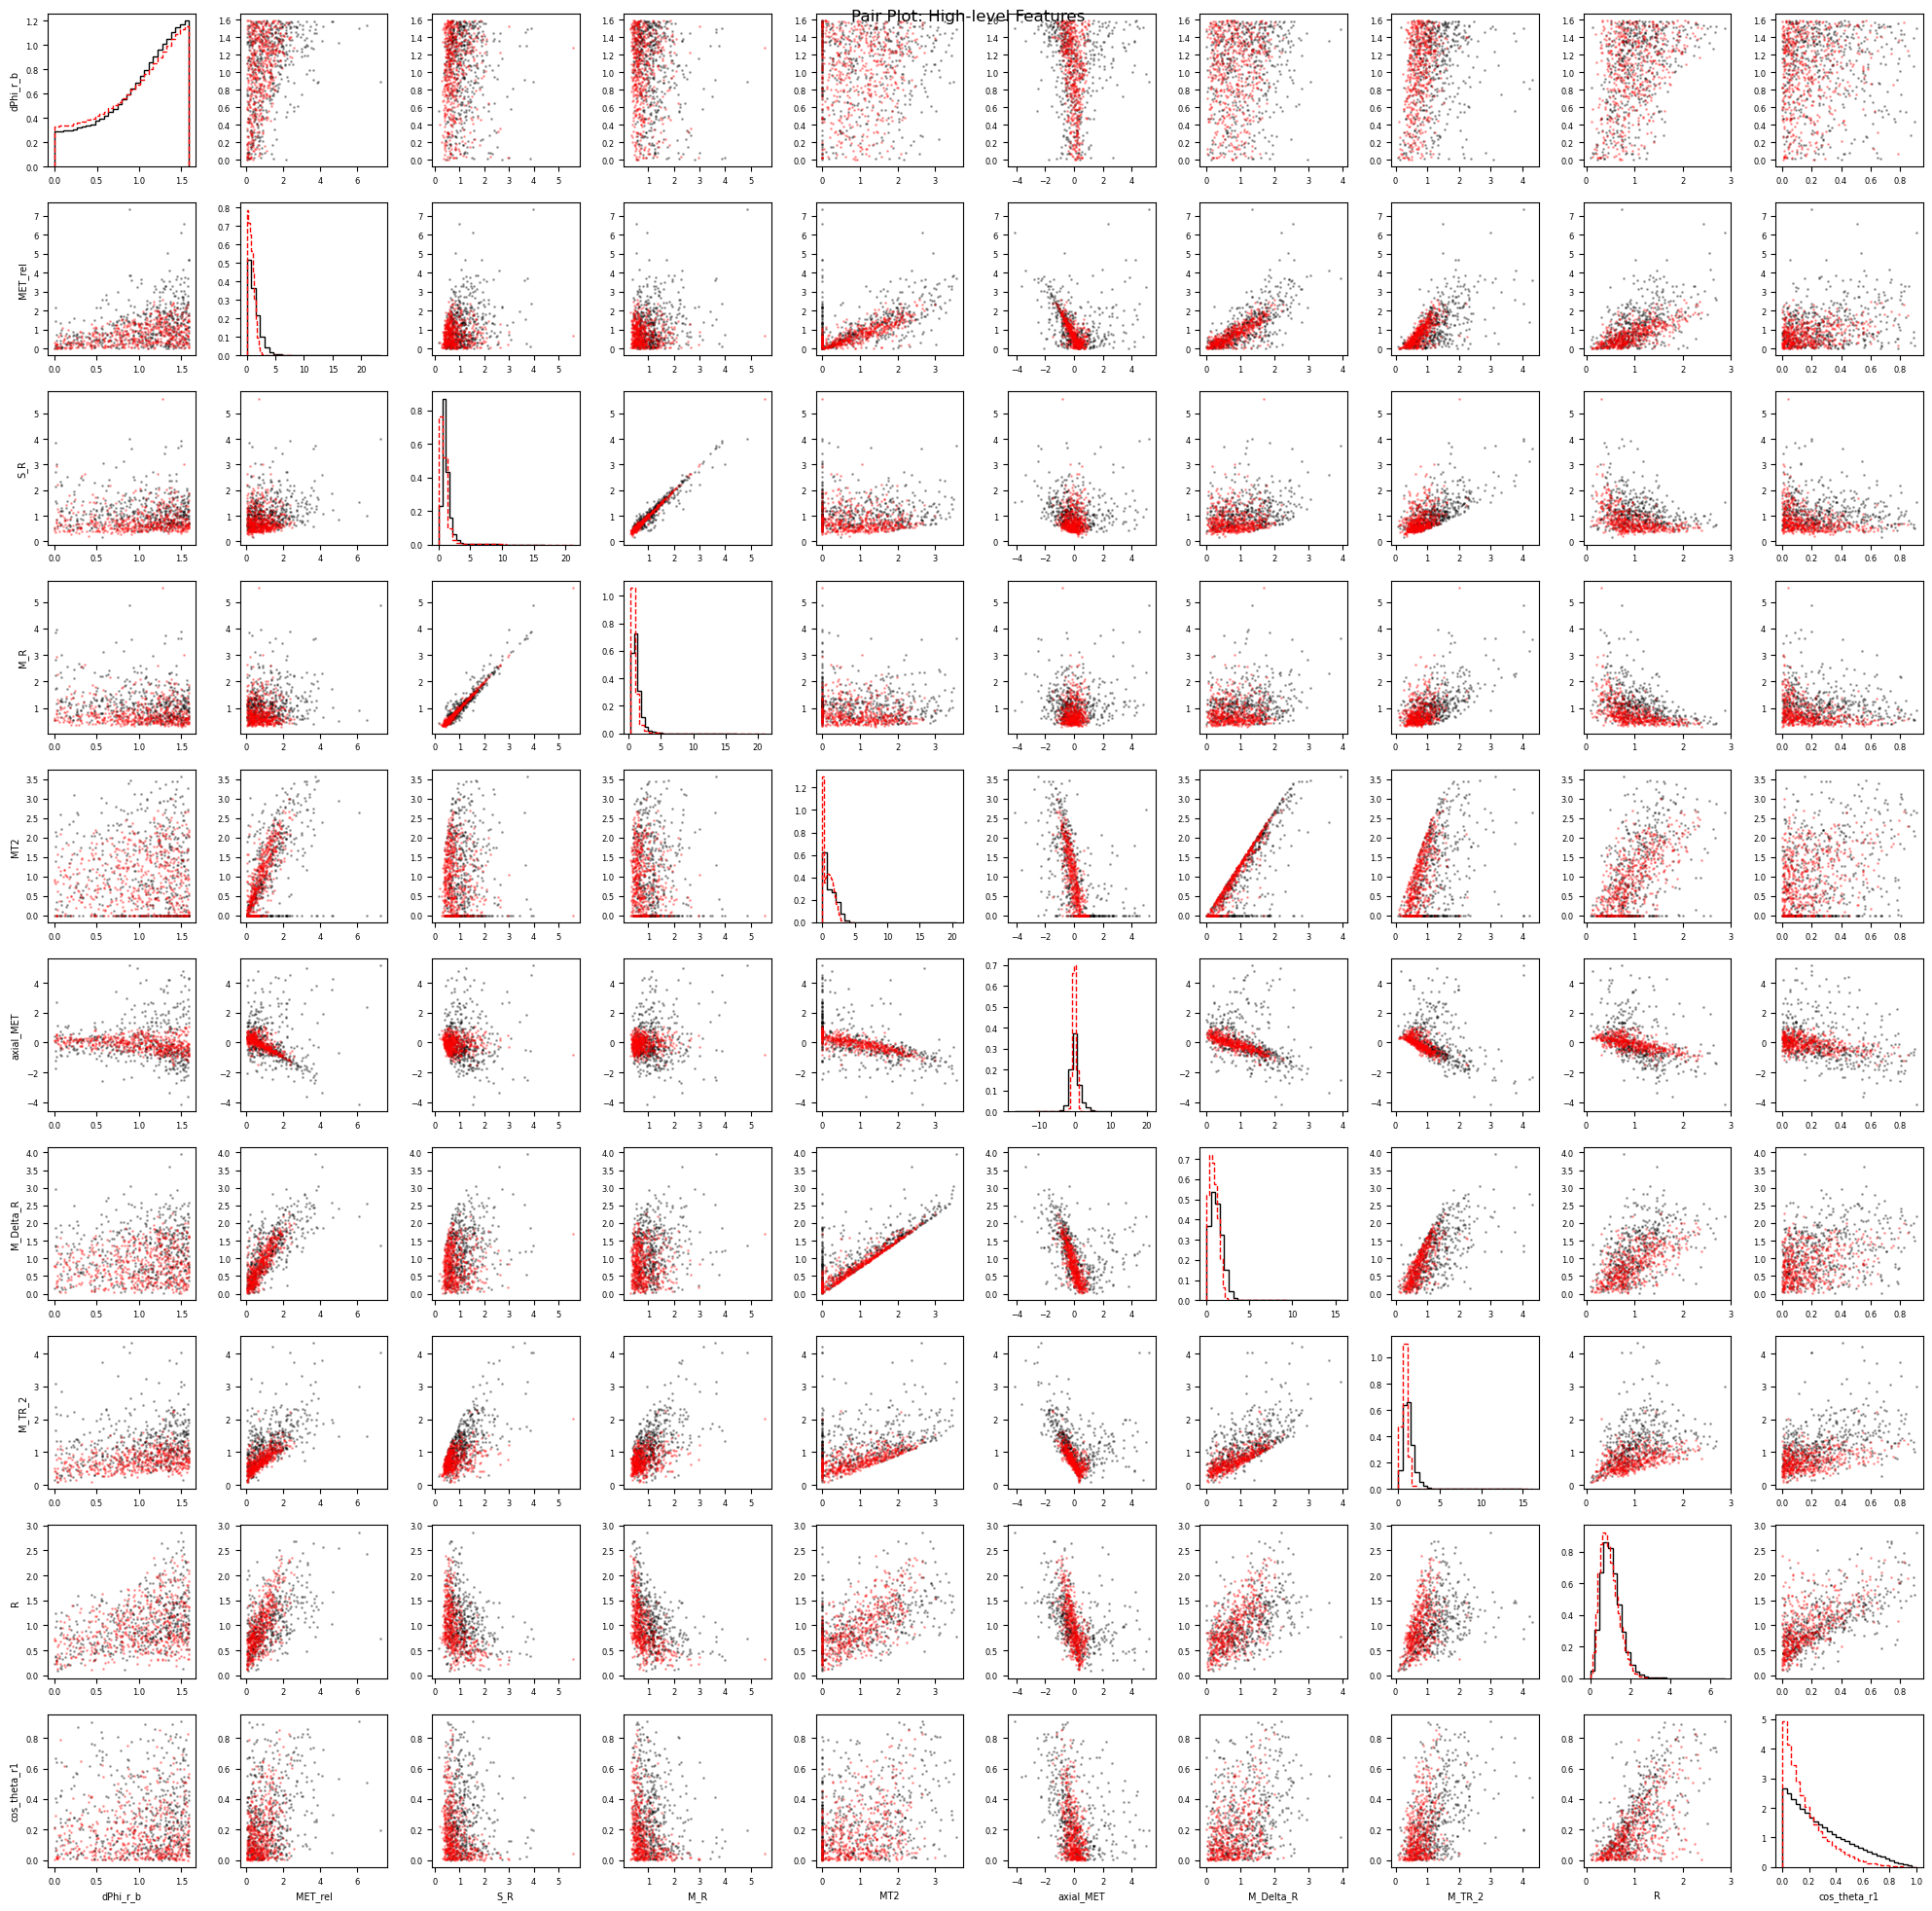

In [11]:
# 4.1.a

def pair_plot(df_sig, df_bkg, varlist, title="Pair Plot"):
    n = len(varlist)
    fig, axes = plt.subplots(n, n, figsize=(2*n, 2*n))
    
    for i in range(n):
        for j in range(n):
            ax = axes[i][j]
            if i == j:
                # Diagonal: 1D histogram
                ax.hist(np.array(df_sig[varlist[i]]), bins=30, density=True,
                        histtype='step', color='black', linewidth=1)
                ax.hist(np.array(df_bkg[varlist[i]]), bins=30, density=True,
                        histtype='step', color='red', linestyle='dashed', linewidth=1)
            else:
                # Off-diagonal: 2D scatter (subsample for speed)
                ax.scatter(df_sig[varlist[j]][:500], df_sig[varlist[i]][:500],
                           s=1, color='black', alpha=0.3)
                ax.scatter(df_bkg[varlist[j]][:500], df_bkg[varlist[i]][:500],
                           s=1, color='red', alpha=0.3)
            if i == n-1:
                ax.set_xlabel(varlist[j], fontsize=7)
            if j == 0:
                ax.set_ylabel(varlist[i], fontsize=7)
            ax.tick_params(labelsize=6)
    
    plt.suptitle(title, fontsize=12)
    plt.tight_layout()
    plt.show()

# Low-level pair plot
pair_plot(df_sig, df_bkg, RawNames, title="Pair Plot: Low-level Features")

# High-level pair plot
pair_plot(df_sig, df_bkg, FeatureNames, title="Pair Plot: High-level Features")

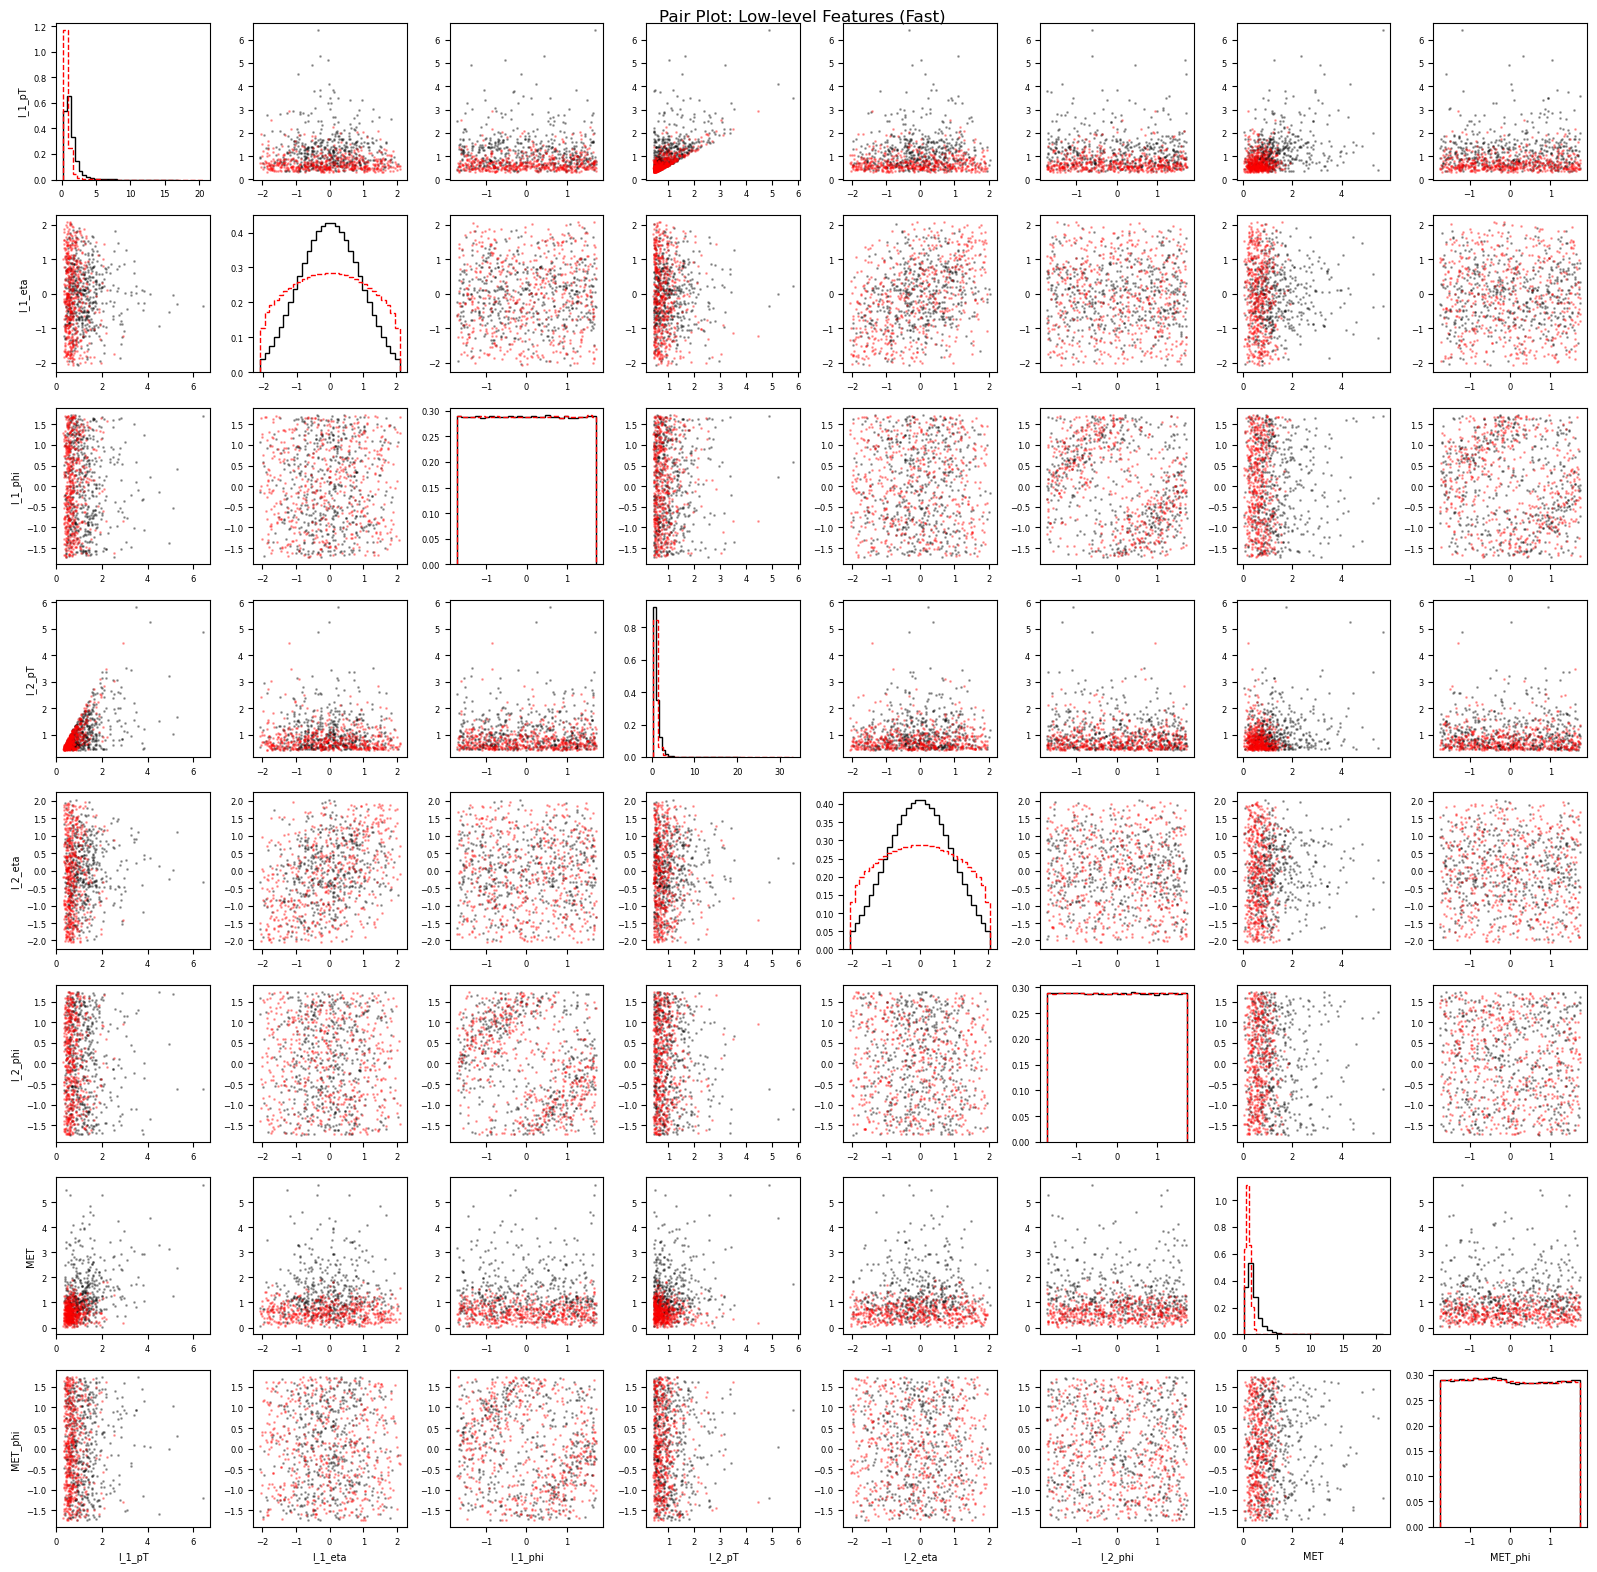

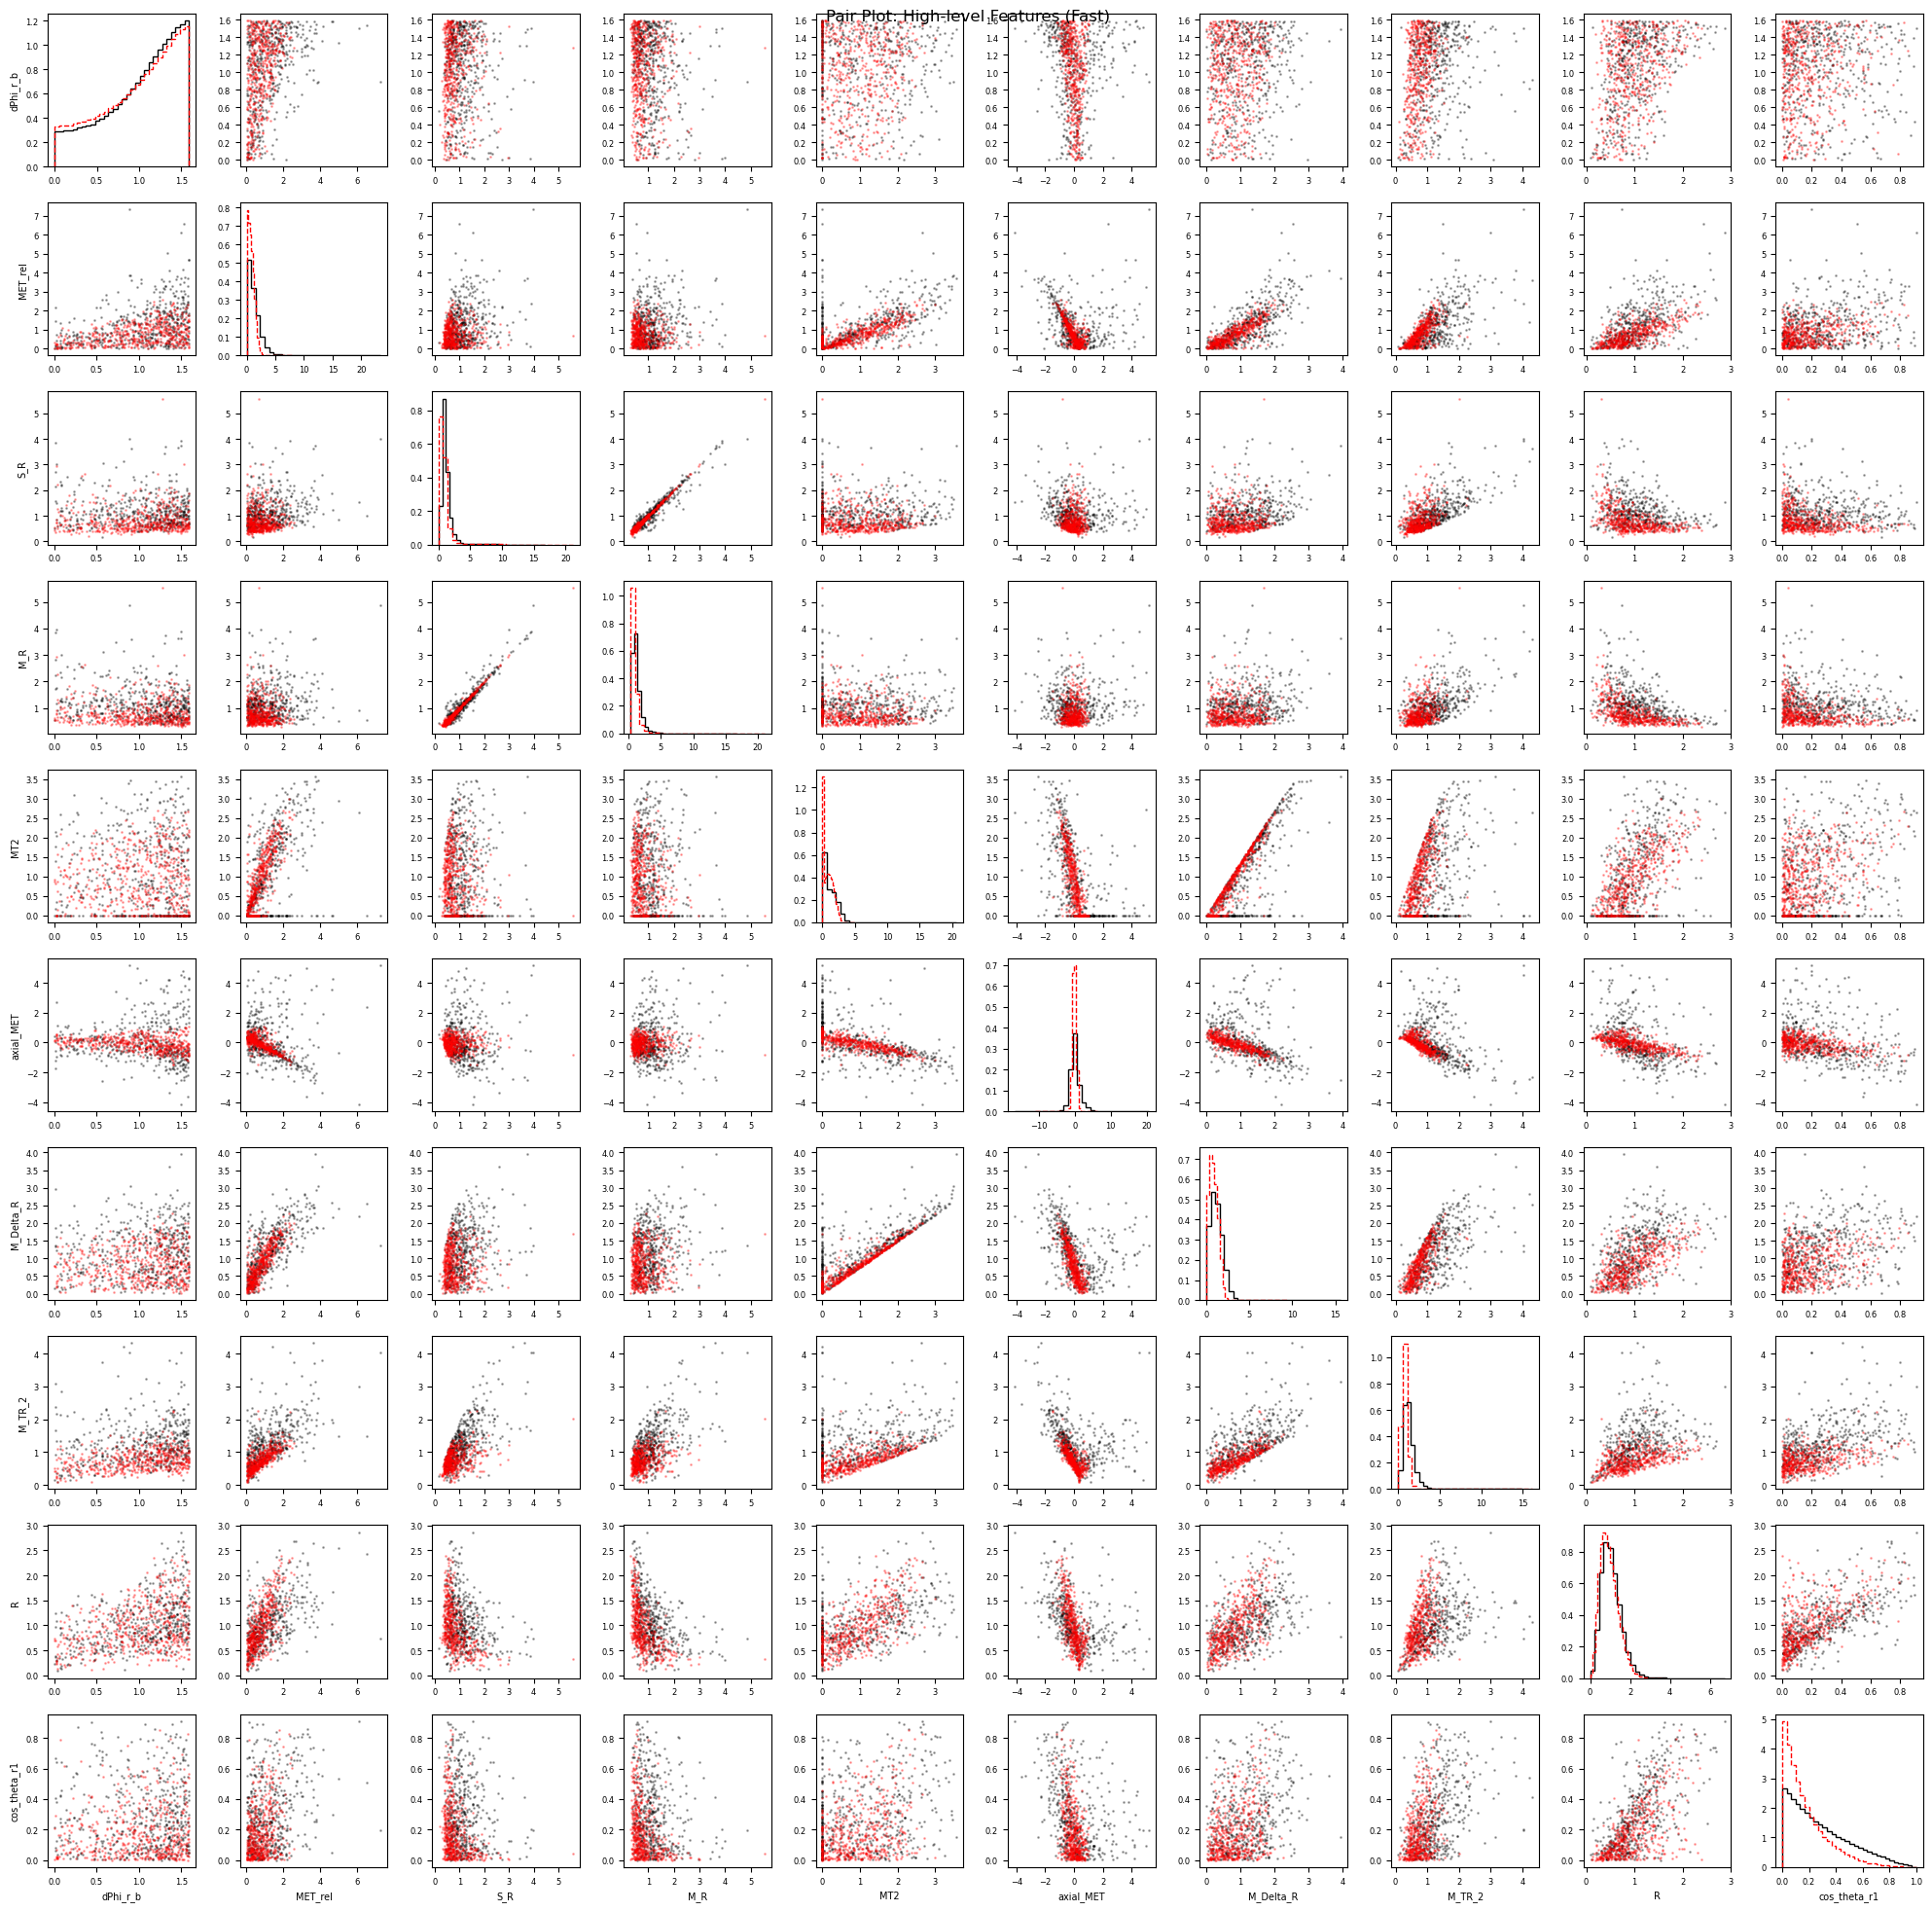

In [14]:
# 4.1.b

def pair_plot_fast(df_sig, df_bkg, varlist, title="Pair Plot", n_scatter=500):
    n = len(varlist)
    
    # Pre-converting to numpy once (this is the key speedup)
    sig_arrays = {v: np.array(df_sig[v]) for v in varlist}
    bkg_arrays = {v: np.array(df_bkg[v]) for v in varlist}
    
    fig, axes = plt.subplots(n, n, figsize=(2*n, 2*n))
    
    for i in range(n):
        for j in range(n):
            ax = axes[i][j]
            if i == j:
                ax.hist(sig_arrays[varlist[i]], bins=30, density=True,
                        histtype='step', color='black', linewidth=1)
                ax.hist(bkg_arrays[varlist[i]], bins=30, density=True,
                        histtype='step', color='red', linestyle='dashed', linewidth=1)
            else:
                ax.scatter(sig_arrays[varlist[j]][:n_scatter],
                           sig_arrays[varlist[i]][:n_scatter],
                           s=1, color='black', alpha=0.3)
                ax.scatter(bkg_arrays[varlist[j]][:n_scatter],
                           bkg_arrays[varlist[i]][:n_scatter],
                           s=1, color='red', alpha=0.3)
            if i == n-1:
                ax.set_xlabel(varlist[j], fontsize=7)
            if j == 0:
                ax.set_ylabel(varlist[i], fontsize=7)
            ax.tick_params(labelsize=6)
    
    plt.suptitle(title, fontsize=12)
    plt.tight_layout()
    plt.show()

pair_plot_fast(df_sig, df_bkg, RawNames, title="Pair Plot: Low-level Features (Fast)")
pair_plot_fast(df_sig, df_bkg, FeatureNames, title="Pair Plot: High-level Features (Fast)")

# Claude helped with the pre-conversion

In [15]:
# 4.1.c

print('''Visual inspection of the pair plots and histograms shows:
- Best separating lower variables: l_1_pT, l_2_pT, MET
- Best separating higher variables: M_Delta_R, R, axial_MET, MET_rel
- High-level features generally show better separation than raw kinematics, similar to what the findings of the paper
''')

Visual inspection of the pair plots and histograms shows:
- Best separating lower variables: l_1_pT, l_2_pT, MET
- Best separating higher variables: M_Delta_R, R, axial_MET, MET_rel
- High-level features generally show better separation than raw kinematics, similar to what the findings of the paper



In [32]:
# 4.2.a

import sys
sys.path.append('/home/mahim/.local/lib/python3.12/site-packages')
import tabulate as tab
print("works:", tab.__version__)
# Generated by claude after repeated attempts and rewrites as 4.2.c would not run

works: 0.10.0


In [30]:
# 4.2.b

import numpy as np

# All features
data_all = df[VarNames[1:]].dropna().to_numpy().T
cov_all  = np.cov(data_all)
corr_all = np.corrcoef(data_all)

# Low-level only
data_raw = df[RawNames].dropna().to_numpy().T
cov_raw  = np.cov(data_raw)
corr_raw = np.corrcoef(data_raw)

# High-level only
data_feat = df[FeatureNames].dropna().to_numpy().T
cov_feat  = np.cov(data_feat)
corr_feat = np.corrcoef(data_feat)

print("Matrices computed.")

Matrices computed.


In [33]:
# 4.2.c

import tabulate as tab
from IPython.display import HTML, display

def fmt(matrix):
    return [[f"{val:.3g}" for val in row] for row in matrix]

print("--- Covariance Matrix: All Features ---")
display(HTML(tab.tabulate(fmt(cov_all), headers=VarNames[1:], showindex=VarNames[1:], tablefmt='html')))

print("--- Correlation Matrix: All Features ---")
display(HTML(tab.tabulate(fmt(corr_all), headers=VarNames[1:], showindex=VarNames[1:], tablefmt='html')))

print("--- Covariance Matrix: Low-level ---")
display(HTML(tab.tabulate(fmt(cov_raw), headers=RawNames, showindex=RawNames, tablefmt='html')))

print("--- Correlation Matrix: Low-level ---")
display(HTML(tab.tabulate(fmt(corr_raw), headers=RawNames, showindex=RawNames, tablefmt='html')))

print("--- Covariance Matrix: High-level ---")
display(HTML(tab.tabulate(fmt(cov_feat), headers=FeatureNames, showindex=FeatureNames, tablefmt='html')))

print("--- Correlation Matrix: High-level ---")
display(HTML(tab.tabulate(fmt(corr_feat), headers=FeatureNames, showindex=FeatureNames, tablefmt='html')))

--- Covariance Matrix: All Features ---


,l_1_pT,l_1_eta,l_1_phi,l_2_pT,l_2_eta,l_2_phi,MET,MET_phi,MET_rel,axial_MET,M_R,M_TR_2,R,MT2,S_R,M_Delta_R,dPhi_r_b,cos_theta_r1
l_1_pT,0.472,-0.000263,-0.000229,0.308,-0.000302,0.000227,0.231,-0.000676,0.0986,-0.0125,0.368,0.291,-0.0593,-0.0128,0.346,0.0981,-0.047,0.0225
l_1_eta,-0.000263,1.01,0.000322,-0.000378,0.406,0.000297,-0.000558,-0.000541,-0.000497,-0.000498,-0.000308,-0.000266,0.000128,-0.000158,-0.000281,-0.000504,7.96e-05,0.000146
l_1_phi,-0.000229,0.000322,1,-0.000129,0.000641,-0.268,0.0012,-0.184,0.00153,-0.00196,-0.0002,0.000838,0.000876,0.00175,4.5e-05,0.00131,0.000954,0.000299
l_2_pT,0.308,-0.000378,-0.000129,0.428,-0.000454,0.000115,0.0797,-0.00139,-0.00226,0.0498,0.328,0.164,-0.0993,-0.0691,0.325,0.00555,-0.00412,-0.0278
l_2_eta,-0.000302,0.406,0.000641,-0.000454,1.01,-6.47e-05,5.12e-05,-0.000126,0.00013,-0.00017,-0.000549,-0.000167,0.000253,-9.06e-05,-0.000554,-0.000215,-5.16e-05,0.000199
l_2_phi,0.000227,0.000297,-0.268,0.000115,-6.47e-05,1,4.32e-06,-0.0345,0.000214,-9.14e-05,0.000287,0.000288,0.000235,0.00124,0.000384,0.000496,0.000244,-0.000199
MET,0.231,-0.000558,0.0012,0.0797,5.12e-05,4.32e-06,0.762,-0.00162,0.548,0.145,0.146,0.368,0.189,0.156,0.167,0.317,0.145,0.0733
MET_phi,-0.000676,-0.000541,-0.184,-0.00139,-0.000126,-0.0345,-0.00162,1,-0.00292,-0.000953,-0.000976,-0.000842,-0.000163,0.000505,-0.00114,-0.000399,-0.00132,5.78e-05
MET_rel,0.0986,-0.000497,0.00153,-0.00226,0.00013,0.000214,0.548,-0.00292,0.792,-0.125,0.0437,0.303,0.25,0.41,0.0824,0.416,0.147,0.0556
axial_MET,-0.0125,-0.000498,-0.00196,0.0498,-0.00017,-9.14e-05,0.145,-0.000953,-0.125,1,0.0151,-0.189,-0.182,-0.46,-0.0434,-0.234,-0.0262,-0.0541


--- Correlation Matrix: All Features ---


,l_1_pT,l_1_eta,l_1_phi,l_2_pT,l_2_eta,l_2_phi,MET,MET_phi,MET_rel,axial_MET,M_R,M_TR_2,R,MT2,S_R,M_Delta_R,dPhi_r_b,cos_theta_r1
l_1_pT,1,-0.000381,-0.000333,0.685,-0.000439,0.00033,0.385,-0.000982,0.161,-0.0182,0.852,0.724,-0.183,-0.0216,0.812,0.229,-0.157,0.166
l_1_eta,-0.000381,1,0.00032,-0.000576,0.403,0.000296,-0.000637,-0.000538,-0.000556,-0.000495,-0.000488,-0.000454,0.00027,-0.000183,-0.000452,-0.000806,0.000182,0.000738
l_1_phi,-0.000333,0.00032,1,-0.000196,0.000638,-0.267,0.00137,-0.184,0.00171,-0.00196,-0.000317,0.00143,0.00186,0.00204,7.23e-05,0.0021,0.00218,0.00152
l_2_pT,0.685,-0.000576,-0.000196,1,-0.000692,0.000175,0.14,-0.00212,-0.00388,0.076,0.798,0.43,-0.322,-0.123,0.799,0.0136,-0.0144,-0.216
l_2_eta,-0.000439,0.403,0.000638,-0.000692,1,-6.44e-05,5.85e-05,-0.000125,0.000145,-0.000169,-0.00087,-0.000285,0.000537,-0.000105,-0.000889,-0.000343,-0.000118,0.00101
l_2_phi,0.00033,0.000296,-0.267,0.000175,-6.44e-05,1,4.94e-06,-0.0344,0.00024,-9.11e-05,0.000455,0.000492,0.000498,0.00144,0.000617,0.000794,0.000558,-0.00101
MET,0.385,-0.000637,0.00137,0.14,5.85e-05,4.94e-06,1,-0.00185,0.706,0.166,0.266,0.722,0.459,0.209,0.309,0.581,0.382,0.426
MET_phi,-0.000982,-0.000538,-0.184,-0.00212,-0.000125,-0.0344,-0.00185,1,-0.00327,-0.00095,-0.00155,-0.00144,-0.000346,0.000587,-0.00183,-0.000638,-0.00303,0.000293
MET_rel,0.161,-0.000556,0.00171,-0.00388,0.000145,0.00024,0.706,-0.00327,1,-0.141,0.0781,0.583,0.595,0.536,0.149,0.749,0.378,0.317
axial_MET,-0.0182,-0.000495,-0.00196,0.076,-0.000169,-9.11e-05,0.166,-0.00095,-0.141,1,0.024,-0.323,-0.385,-0.535,-0.0698,-0.375,-0.06,-0.274


--- Covariance Matrix: Low-level ---


...

,l_1_pT,l_1_eta,l_1_phi,l_2_pT,l_2_eta,l_2_phi,MET,MET_phi
l_1_pT,1,-0.000381,-0.000333,0.685,-0.000439,0.00033,0.385,-0.000982
l_1_eta,-0.000381,1,0.00032,-0.000576,0.403,0.000296,-0.000637,-0.000538
l_1_phi,-0.000333,0.00032,1,-0.000196,0.000638,-0.267,0.00137,-0.184
l_2_pT,0.685,-0.000576,-0.000196,1,-0.000692,0.000175,0.14,-0.00212
l_2_eta,-0.000439,0.403,0.000638,-0.000692,1,-6.44e-05,5.85e-05,-0.000125
l_2_phi,0.00033,0.000296,-0.267,0.000175,-6.44e-05,1,4.94e-06,-0.0344
MET,0.385,-0.000637,0.00137,0.14,5.85e-05,4.94e-06,1,-0.00185
MET_phi,-0.000982,-0.000538,-0.184,-0.00212,-0.000125,-0.0344,-0.00185,1


--- Covariance Matrix: High-level ---


,axial_MET,MET_rel,M_Delta_R,cos_theta_r1,M_R,R,M_TR_2,MT2,dPhi_r_b,S_R
axial_MET,1,-0.125,-0.234,-0.0541,0.0151,-0.182,-0.189,-0.46,-0.0262,-0.0434
MET_rel,-0.125,0.792,0.416,0.0556,0.0437,0.25,0.303,0.41,0.147,0.0824
M_Delta_R,-0.234,0.416,0.389,0.0392,0.0743,0.166,0.242,0.433,0.0424,0.0961
cos_theta_r1,-0.0541,0.0556,0.0392,0.0388,-0.0142,0.0582,0.0519,0.0445,0.00913,-0.0102
M_R,0.0151,0.0437,0.0743,-0.0142,0.395,-0.113,0.212,-0.0366,-0.0291,0.383
R,-0.182,0.25,0.166,0.0582,-0.113,0.222,0.104,0.232,0.0871,-0.0834
M_TR_2,-0.189,0.303,0.242,0.0519,0.212,0.104,0.341,0.189,0.0581,0.23
MT2,-0.46,0.41,0.433,0.0445,-0.0366,0.232,0.189,0.738,0.0212,-0.0112
dPhi_r_b,-0.0262,0.147,0.0424,0.00913,-0.0291,0.0871,0.0581,0.0212,0.19,-0.00363
S_R,-0.0434,0.0824,0.0961,-0.0102,0.383,-0.0834,0.23,-0.0112,-0.00363,0.385


--- Correlation Matrix: High-level ---


,axial_MET,MET_rel,M_Delta_R,cos_theta_r1,M_R,R,M_TR_2,MT2,dPhi_r_b,S_R
axial_MET,1,-0.141,-0.375,-0.274,0.024,-0.385,-0.323,-0.535,-0.06,-0.0698
MET_rel,-0.141,1,0.749,0.317,0.0781,0.595,0.583,0.536,0.378,0.149
M_Delta_R,-0.375,0.749,1,0.319,0.189,0.564,0.666,0.808,0.156,0.248
cos_theta_r1,-0.274,0.317,0.319,1,-0.115,0.627,0.451,0.263,0.106,-0.0836
M_R,0.024,0.0781,0.189,-0.115,1,-0.381,0.578,-0.0678,-0.106,0.981
R,-0.385,0.595,0.564,0.627,-0.381,1,0.38,0.574,0.424,-0.285
M_TR_2,-0.323,0.583,0.666,0.451,0.578,0.38,1,0.378,0.228,0.636
MT2,-0.535,0.536,0.808,0.263,-0.0678,0.574,0.378,1,0.0565,-0.0209
dPhi_r_b,-0.06,0.378,0.156,0.106,-0.106,0.424,0.228,0.0565,1,-0.0134
S_R,-0.0698,0.149,0.248,-0.0836,0.981,-0.285,0.636,-0.0209,-0.0134,1


In [34]:
# 4.2.d

def cov_corr_tables(df, varlist, label=""):
    data = df[varlist].dropna().to_numpy().T
    cov_matrix  = np.cov(data)
    corr_matrix = np.corrcoef(data)
    
    def fmt(matrix):
        return [[f"{val:.3g}" for val in row] for row in matrix]
    
    print(f"--- Covariance Matrix: {label} ---")
    display(HTML(tab.tabulate(fmt(cov_matrix),  headers=varlist, showindex=varlist, tablefmt='html')))
    
    print(f"--- Correlation Matrix: {label} ---")
    display(HTML(tab.tabulate(fmt(corr_matrix), headers=varlist, showindex=varlist, tablefmt='html')))

# Test
cov_corr_tables(df, VarNames[1:], label="All Features")

--- Covariance Matrix: All Features ---


,l_1_pT,l_1_eta,l_1_phi,l_2_pT,l_2_eta,l_2_phi,MET,MET_phi,MET_rel,axial_MET,M_R,M_TR_2,R,MT2,S_R,M_Delta_R,dPhi_r_b,cos_theta_r1
l_1_pT,0.472,-0.000263,-0.000229,0.308,-0.000302,0.000227,0.231,-0.000676,0.0986,-0.0125,0.368,0.291,-0.0593,-0.0128,0.346,0.0981,-0.047,0.0225
l_1_eta,-0.000263,1.01,0.000322,-0.000378,0.406,0.000297,-0.000558,-0.000541,-0.000497,-0.000498,-0.000308,-0.000266,0.000128,-0.000158,-0.000281,-0.000504,7.96e-05,0.000146
l_1_phi,-0.000229,0.000322,1,-0.000129,0.000641,-0.268,0.0012,-0.184,0.00153,-0.00196,-0.0002,0.000838,0.000876,0.00175,4.5e-05,0.00131,0.000954,0.000299
l_2_pT,0.308,-0.000378,-0.000129,0.428,-0.000454,0.000115,0.0797,-0.00139,-0.00226,0.0498,0.328,0.164,-0.0993,-0.0691,0.325,0.00555,-0.00412,-0.0278
l_2_eta,-0.000302,0.406,0.000641,-0.000454,1.01,-6.47e-05,5.12e-05,-0.000126,0.00013,-0.00017,-0.000549,-0.000167,0.000253,-9.06e-05,-0.000554,-0.000215,-5.16e-05,0.000199
l_2_phi,0.000227,0.000297,-0.268,0.000115,-6.47e-05,1,4.32e-06,-0.0345,0.000214,-9.14e-05,0.000287,0.000288,0.000235,0.00124,0.000384,0.000496,0.000244,-0.000199
MET,0.231,-0.000558,0.0012,0.0797,5.12e-05,4.32e-06,0.762,-0.00162,0.548,0.145,0.146,0.368,0.189,0.156,0.167,0.317,0.145,0.0733
MET_phi,-0.000676,-0.000541,-0.184,-0.00139,-0.000126,-0.0345,-0.00162,1,-0.00292,-0.000953,-0.000976,-0.000842,-0.000163,0.000505,-0.00114,-0.000399,-0.00132,5.78e-05
MET_rel,0.0986,-0.000497,0.00153,-0.00226,0.00013,0.000214,0.548,-0.00292,0.792,-0.125,0.0437,0.303,0.25,0.41,0.0824,0.416,0.147,0.0556
axial_MET,-0.0125,-0.000498,-0.00196,0.0498,-0.00017,-9.14e-05,0.145,-0.000953,-0.125,1,0.0151,-0.189,-0.182,-0.46,-0.0434,-0.234,-0.0262,-0.0541


--- Correlation Matrix: All Features ---


,l_1_pT,l_1_eta,l_1_phi,l_2_pT,l_2_eta,l_2_phi,MET,MET_phi,MET_rel,axial_MET,M_R,M_TR_2,R,MT2,S_R,M_Delta_R,dPhi_r_b,cos_theta_r1
l_1_pT,1,-0.000381,-0.000333,0.685,-0.000439,0.00033,0.385,-0.000982,0.161,-0.0182,0.852,0.724,-0.183,-0.0216,0.812,0.229,-0.157,0.166
l_1_eta,-0.000381,1,0.00032,-0.000576,0.403,0.000296,-0.000637,-0.000538,-0.000556,-0.000495,-0.000488,-0.000454,0.00027,-0.000183,-0.000452,-0.000806,0.000182,0.000738
l_1_phi,-0.000333,0.00032,1,-0.000196,0.000638,-0.267,0.00137,-0.184,0.00171,-0.00196,-0.000317,0.00143,0.00186,0.00204,7.23e-05,0.0021,0.00218,0.00152
l_2_pT,0.685,-0.000576,-0.000196,1,-0.000692,0.000175,0.14,-0.00212,-0.00388,0.076,0.798,0.43,-0.322,-0.123,0.799,0.0136,-0.0144,-0.216
l_2_eta,-0.000439,0.403,0.000638,-0.000692,1,-6.44e-05,5.85e-05,-0.000125,0.000145,-0.000169,-0.00087,-0.000285,0.000537,-0.000105,-0.000889,-0.000343,-0.000118,0.00101
l_2_phi,0.00033,0.000296,-0.267,0.000175,-6.44e-05,1,4.94e-06,-0.0344,0.00024,-9.11e-05,0.000455,0.000492,0.000498,0.00144,0.000617,0.000794,0.000558,-0.00101
MET,0.385,-0.000637,0.00137,0.14,5.85e-05,4.94e-06,1,-0.00185,0.706,0.166,0.266,0.722,0.459,0.209,0.309,0.581,0.382,0.426
MET_phi,-0.000982,-0.000538,-0.184,-0.00212,-0.000125,-0.0344,-0.00185,1,-0.00327,-0.00095,-0.00155,-0.00144,-0.000346,0.000587,-0.00183,-0.000638,-0.00303,0.000293
MET_rel,0.161,-0.000556,0.00171,-0.00388,0.000145,0.00024,0.706,-0.00327,1,-0.141,0.0781,0.583,0.595,0.536,0.149,0.749,0.378,0.317
axial_MET,-0.0182,-0.000495,-0.00196,0.076,-0.000169,-9.11e-05,0.166,-0.00095,-0.141,1,0.024,-0.323,-0.385,-0.535,-0.0698,-0.375,-0.06,-0.274


In [24]:
# 5.1

signal     = df[df['signal'] == 1.0]
background = df[df['signal'] == 0.0]

observables = VarNames[1:]

def choose_criterion(var, signal, background):
    sig_vals = signal[var].values
    bg_vals  = background[var].values
    mu_s, sigma_s = np.mean(sig_vals), np.std(sig_vals)
    mu_b, sigma_b = np.mean(bg_vals),  np.std(bg_vals)

    mean_diff   = mu_s - mu_b
    spread_diff = sigma_s - sigma_b

    if abs(mean_diff) >= abs(spread_diff):
        if mean_diff > 0:
            return 1, f"x > x_c  (signal mean {mu_s:.3f} > bg mean {mu_b:.3f})"
        else:
            return 2, f"x < x_c  (signal mean {mu_s:.3f} < bg mean {mu_b:.3f})"
    else:
        if spread_diff > 0:
            return 3, f"|x-μ| > x_c  (signal σ {sigma_s:.3f} > bg σ {sigma_b:.3f})"
        else:
            return 4, f"|x-μ| < x_c  (signal σ {sigma_s:.3f} < bg σ {sigma_b:.3f})"

criteria = {}
print(f"{'Observable':<15} {'Criterion':<5} {'Reasoning'}")
print("-" * 80)
for var in observables:
    c, desc = choose_criterion(var, signal, background)
    criteria[var] = c
    print(f"{var:<15} {c:<5} {desc}")
    
# Needed Claude to help me with the part from "criteria ={}"

Observable      Criterion Reasoning
--------------------------------------------------------------------------------
l_1_pT          1     x > x_c  (signal mean 1.290 > bg mean 0.756)
l_1_eta         4     |x-μ| < x_c  (signal σ 0.865 < bg σ 1.106)
l_1_phi         2     x < x_c  (signal mean -0.001 < bg mean 0.000)
l_2_pT          1     x > x_c  (signal mean 1.138 > bg mean 0.882)
l_2_eta         4     |x-μ| < x_c  (signal σ 0.890 < bg σ 1.089)
l_2_phi         3     |x-μ| > x_c  (signal σ 1.002 > bg σ 1.001)
MET             1     x > x_c  (signal mean 1.417 > bg mean 0.648)
MET_phi         3     |x-μ| > x_c  (signal σ 1.002 > bg σ 1.001)
MET_rel         3     |x-μ| > x_c  (signal σ 1.113 > bg σ 0.548)
axial_MET       3     |x-μ| > x_c  (signal σ 1.382 > bg σ 0.478)
M_R             1     x > x_c  (signal mean 1.183 > bg mean 0.846)
M_TR_2          1     x > x_c  (signal mean 1.269 > bg mean 0.773)
R               1     x > x_c  (signal mean 1.057 > bg mean 0.952)
MT2             3     |

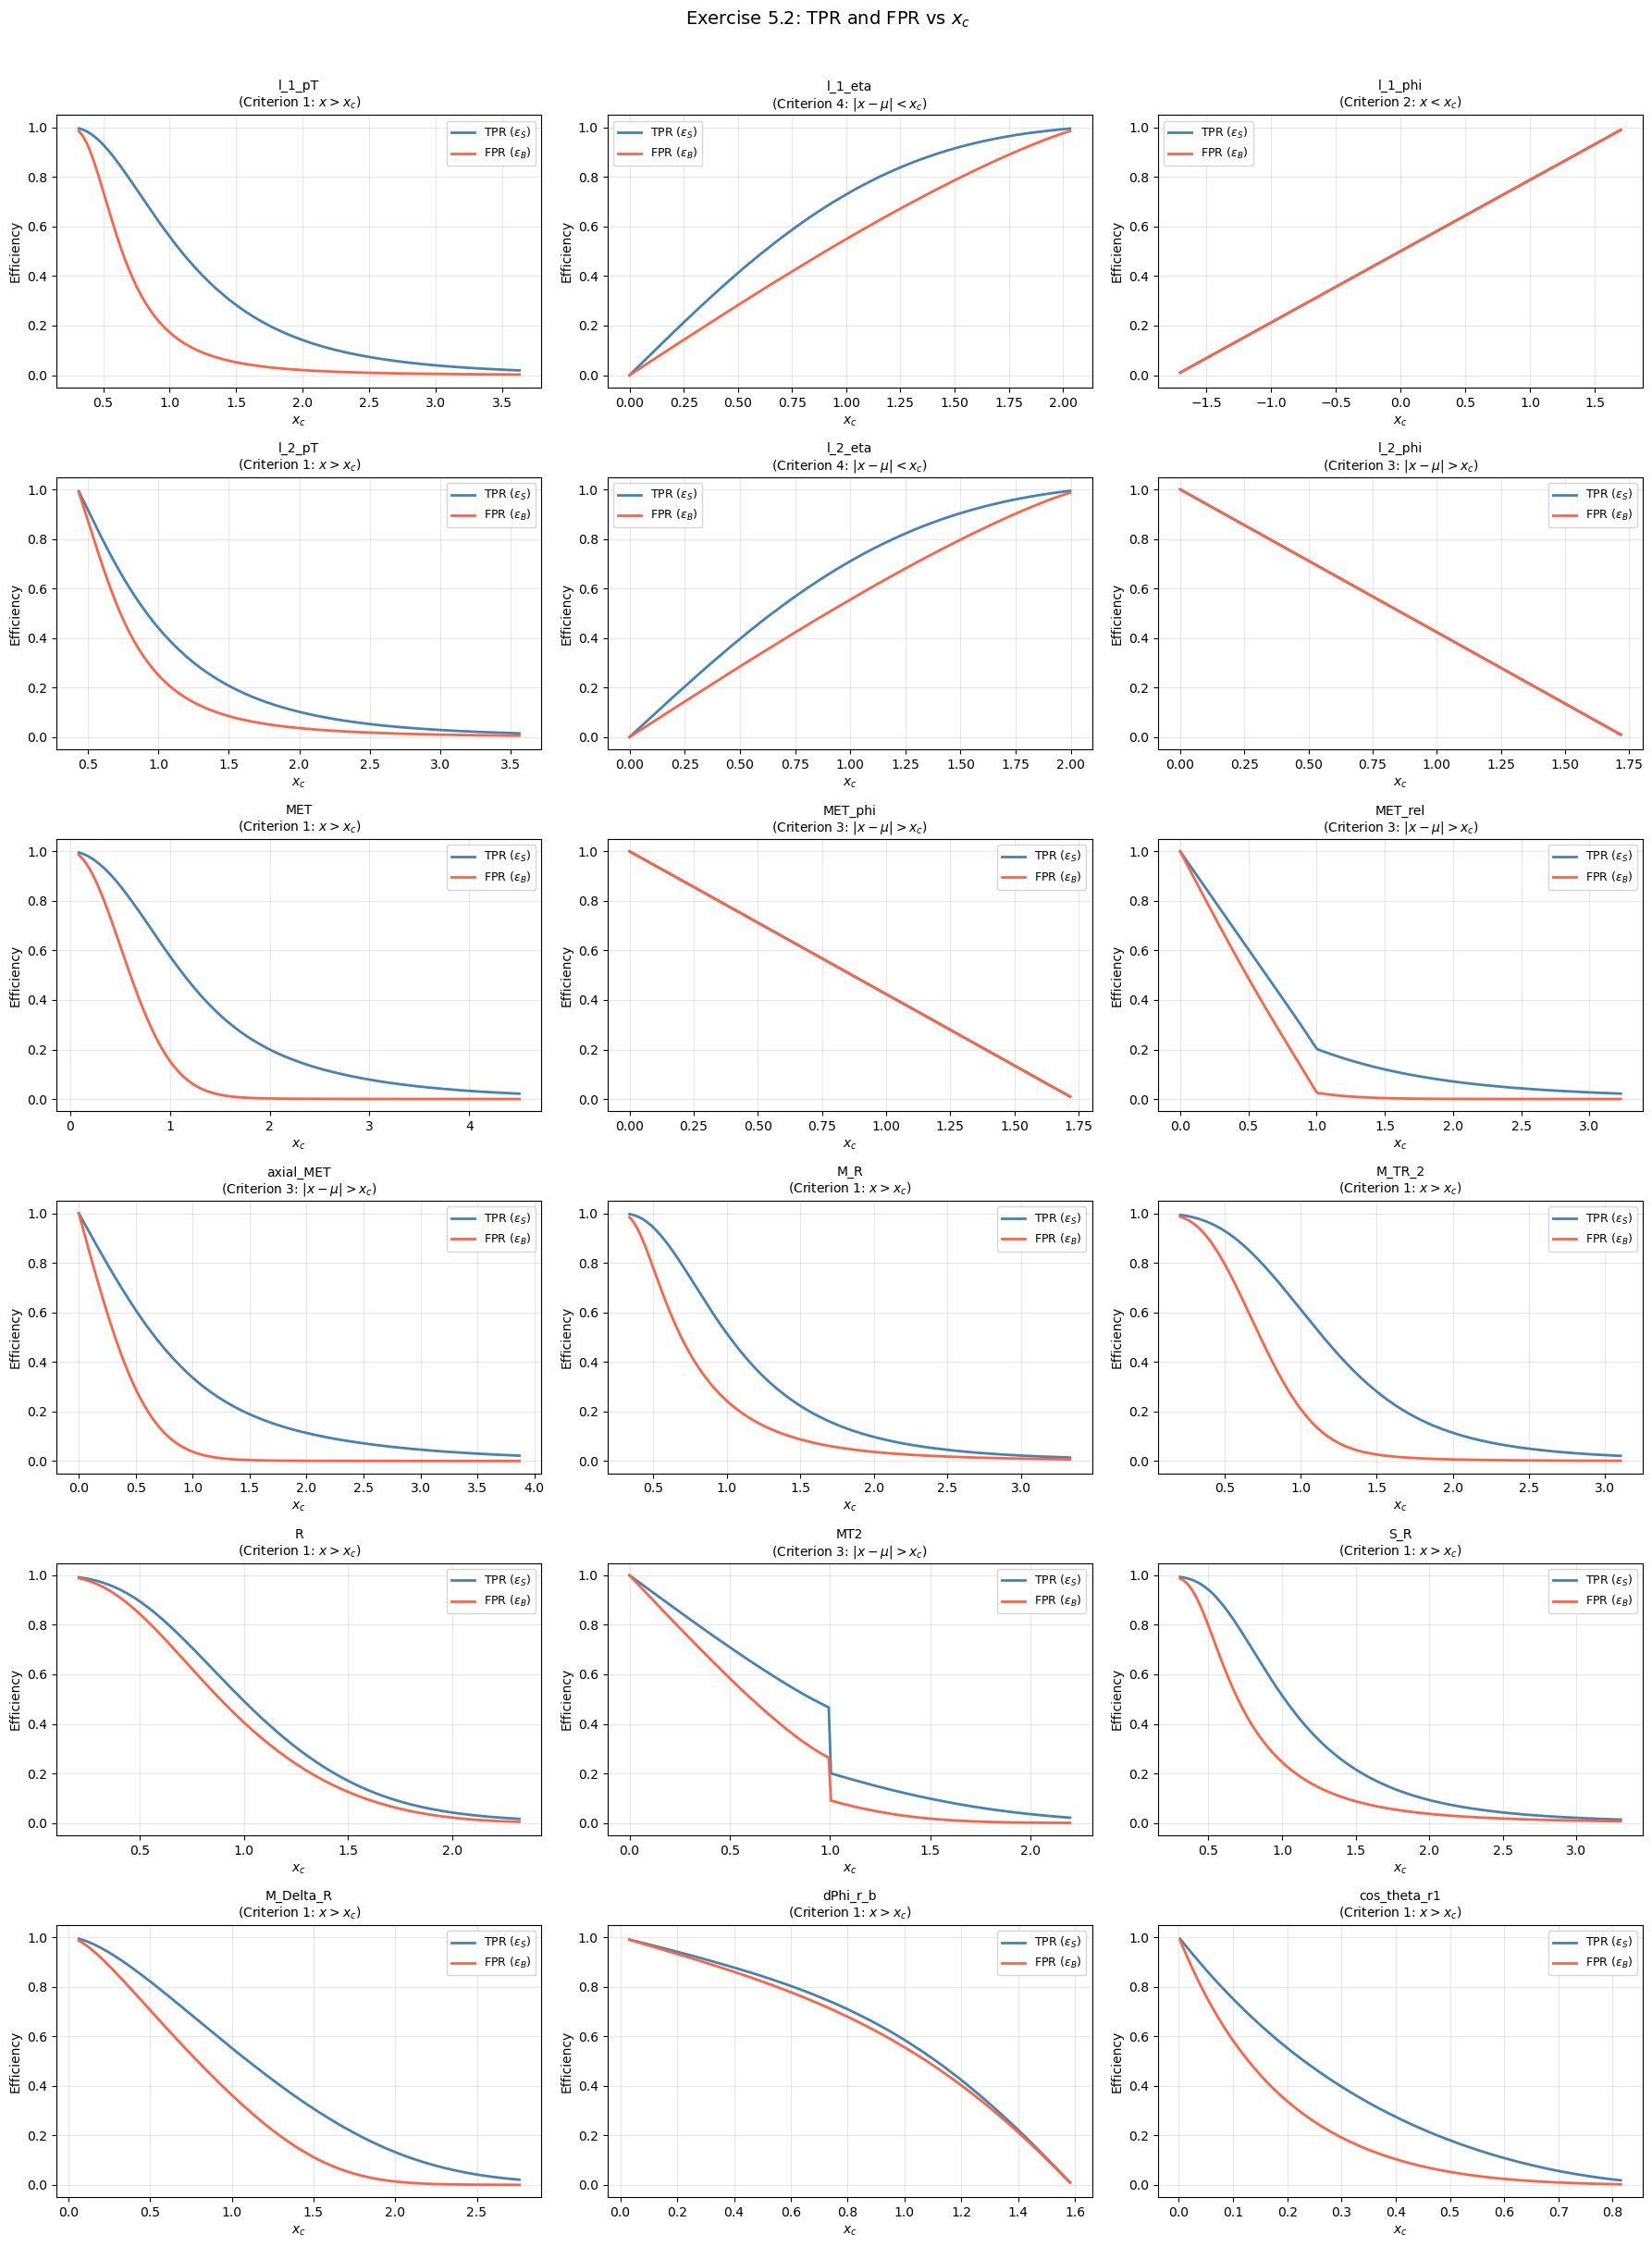

In [26]:
#5.2

def compute_efficiencies(var, criterion, signal, background, n_cuts=200):
    all_vals = np.concatenate([signal[var].values, background[var].values])
    mu = np.mean(all_vals)
    sig_vals = signal[var].values
    bg_vals  = background[var].values
    total_s  = len(sig_vals)
    total_b  = len(bg_vals)

    if criterion in (3, 4):
        xc_array = np.linspace(0, np.percentile(np.abs(all_vals - mu), 99), n_cuts)
    else:
        xc_array = np.linspace(np.percentile(all_vals, 1), np.percentile(all_vals, 99), n_cuts)

    if criterion == 1:
        tpr = np.array([np.sum(sig_vals > xc) / total_s for xc in xc_array])
        fpr = np.array([np.sum(bg_vals  > xc) / total_b for xc in xc_array])
    elif criterion == 2:
        tpr = np.array([np.sum(sig_vals < xc) / total_s for xc in xc_array])
        fpr = np.array([np.sum(bg_vals  < xc) / total_b for xc in xc_array])
    elif criterion == 3:
        tpr = np.array([np.sum(np.abs(sig_vals - mu) > xc) / total_s for xc in xc_array])
        fpr = np.array([np.sum(np.abs(bg_vals  - mu) > xc) / total_b for xc in xc_array])
    else:
        tpr = np.array([np.sum(np.abs(sig_vals - mu) < xc) / total_s for xc in xc_array])
        fpr = np.array([np.sum(np.abs(bg_vals  - mu) < xc) / total_b for xc in xc_array])

    return xc_array, tpr, fpr

efficiencies = {}
criterion_labels = {1: r"$x > x_c$", 2: r"$x < x_c$",
                    3: r"$|x-\mu| > x_c$", 4: r"$|x-\mu| < x_c$"}

ncols = 3
nrows = (len(observables) + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(18, nrows * 4))
axes = axes.flatten()

for i, var in enumerate(observables):
    c = criteria[var]
    xc, tpr, fpr = compute_efficiencies(var, c, signal, background)
    efficiencies[var] = (xc, tpr, fpr)

    ax = axes[i]
    ax.plot(xc, tpr, label=r'TPR ($\epsilon_S$)', color='steelblue', lw=2)
    ax.plot(xc, fpr, label=r'FPR ($\epsilon_B$)', color='tomato',    lw=2)
    ax.set_title(f"{var}\n(Criterion {c}: {criterion_labels[c]})", fontsize=10)
    ax.set_xlabel(r'$x_c$')
    ax.set_ylabel('Efficiency')
    ax.set_ylim(-0.05, 1.05)
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

fig.suptitle(r'Exercise 5.2: TPR and FPR vs $x_c$', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

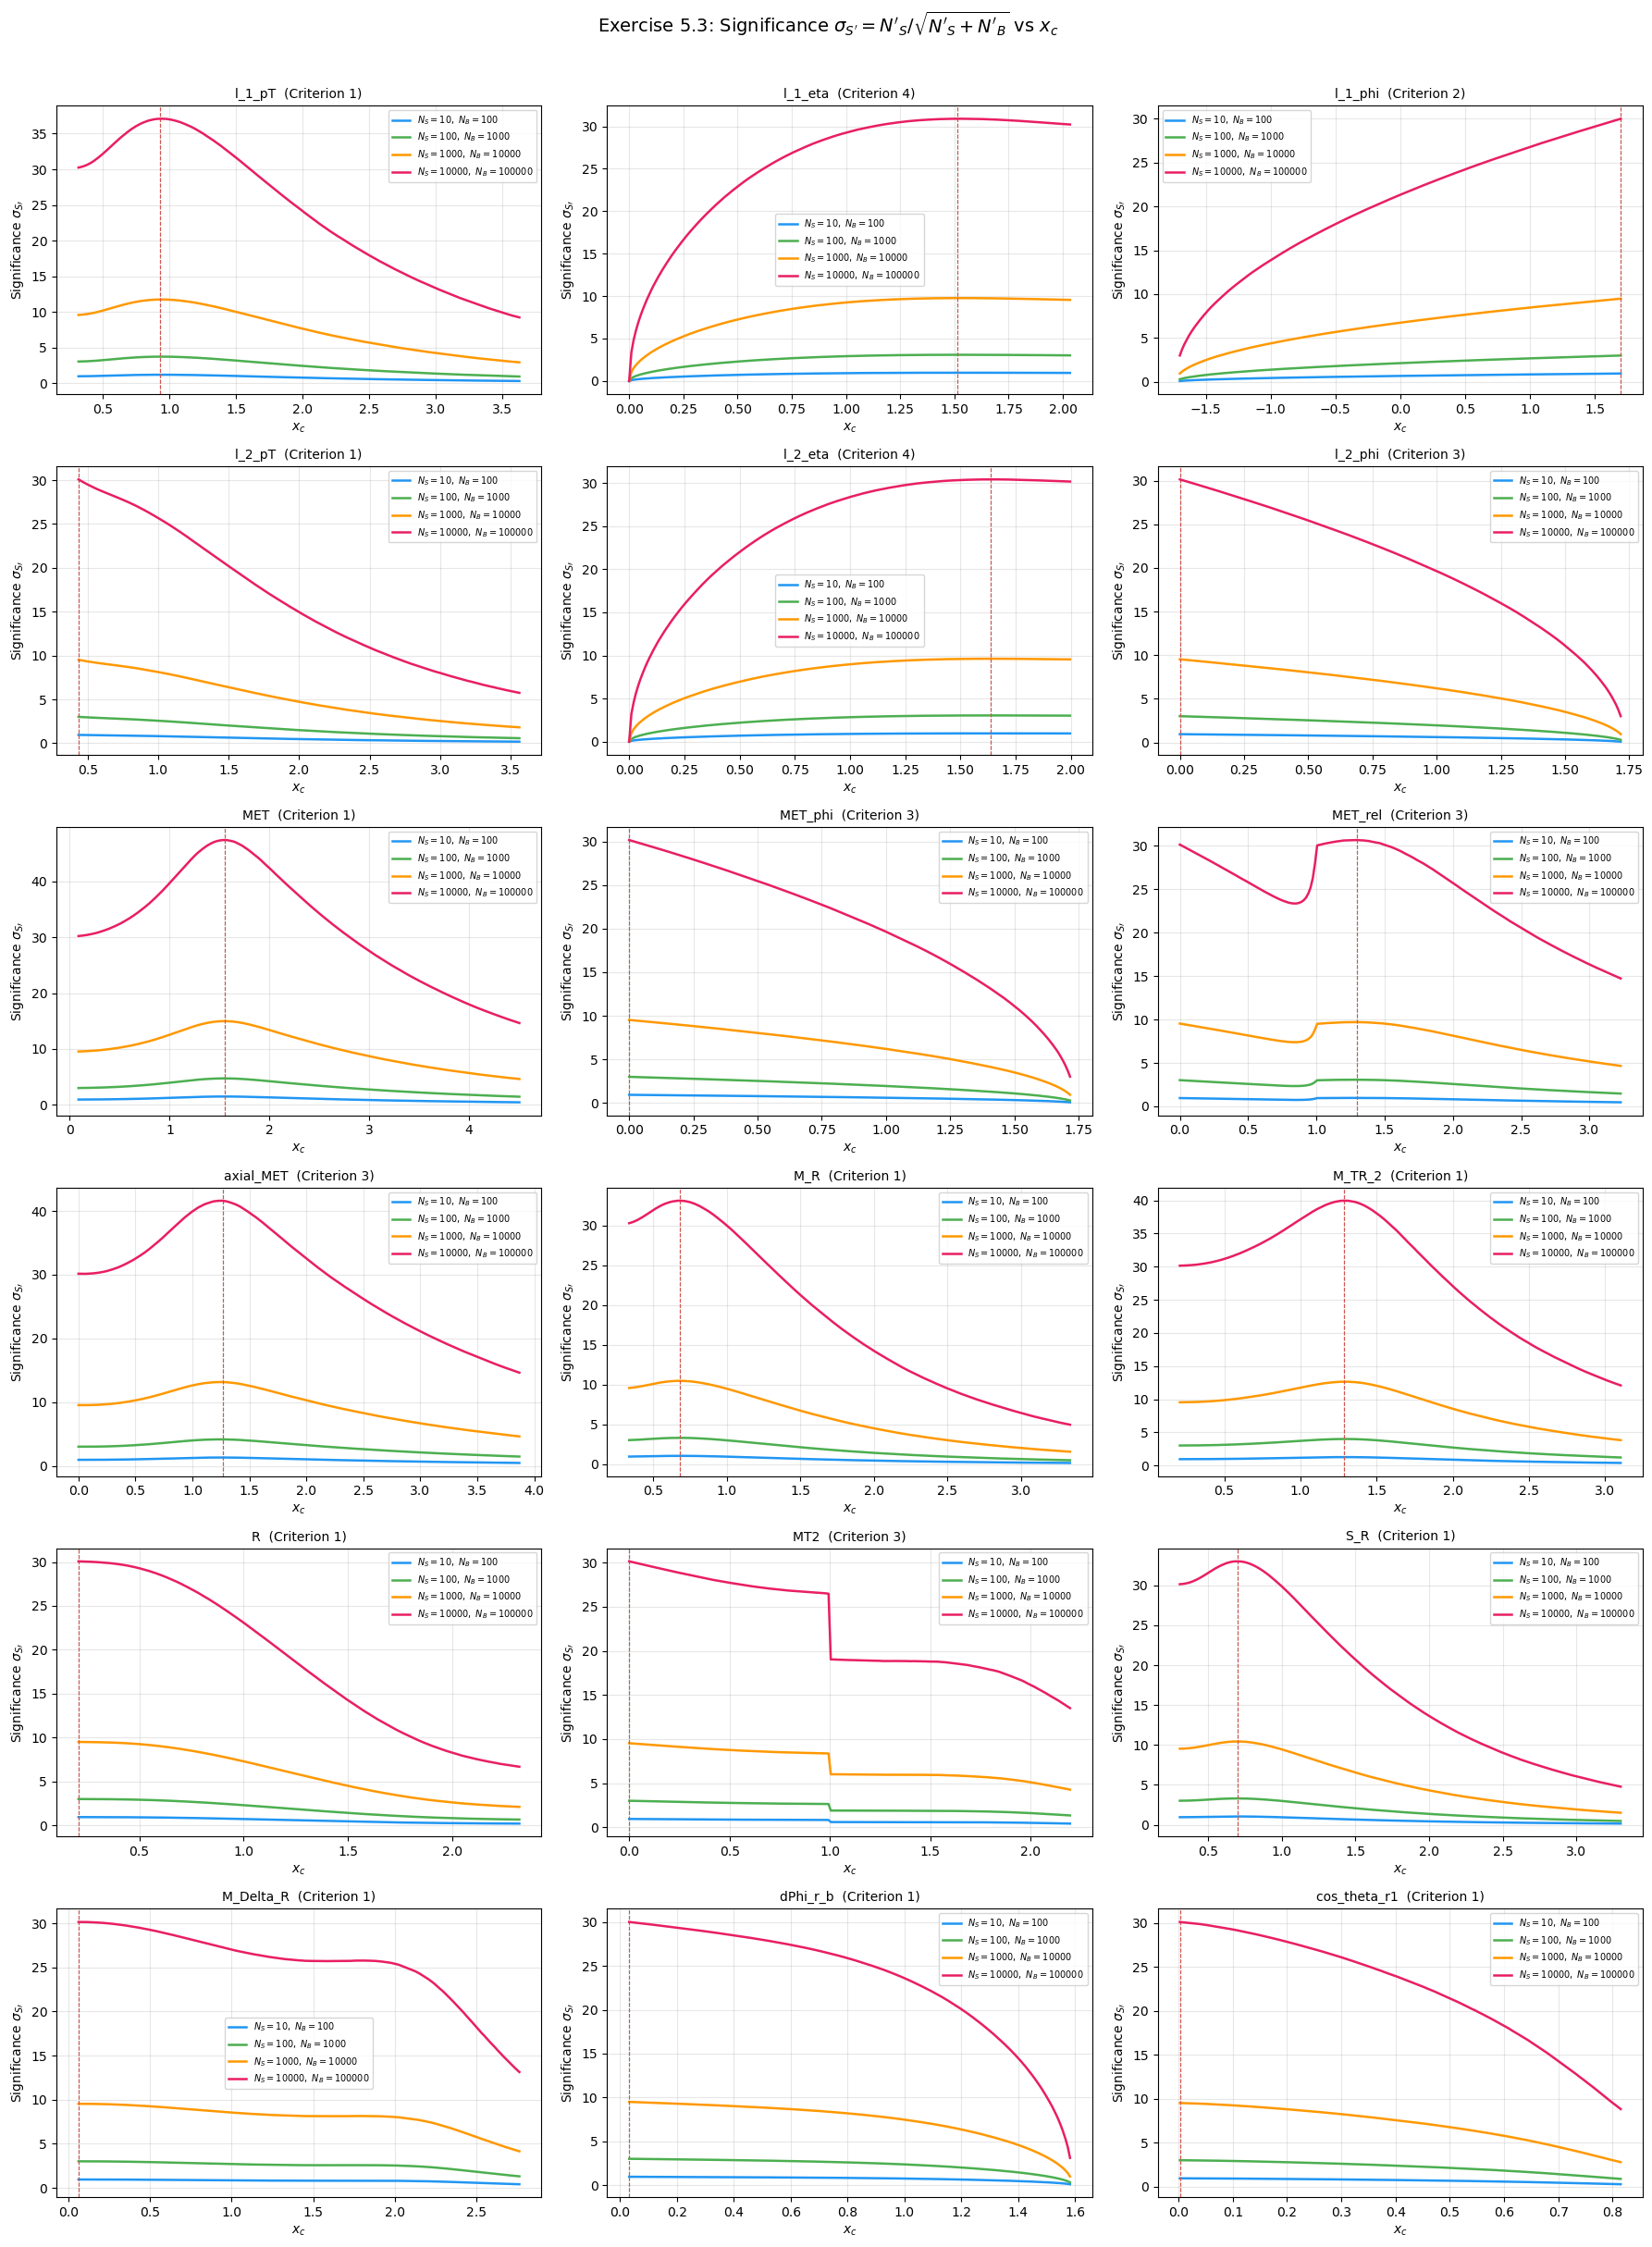

In [27]:
scenarios = [(10, 100), (100, 1000), (1000, 10000), (10000, 100000)]
scenario_colors = ['#2196F3', '#4CAF50', '#FF9800', '#E91E63']
scenario_labels = [f'$N_S={ns},\\ N_B={nb}$' for ns, nb in scenarios]

def significance(tpr, fpr, N_S, N_B):
    Ns_prime = tpr * N_S
    Nb_prime = fpr * N_B
    denom = np.sqrt(Ns_prime + Nb_prime)
    with np.errstate(invalid='ignore', divide='ignore'):
        return np.where(denom > 0, Ns_prime / denom, 0.0)

best_xc = {}
ncols = 3
nrows = (len(observables) + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(18, nrows * 4))
axes = axes.flatten()

for i, var in enumerate(observables):
    xc, tpr, fpr = efficiencies[var]
    ax = axes[i]
    best_xc[var] = {}

    for (N_S, N_B), color, label in zip(scenarios, scenario_colors, scenario_labels):
        sig = significance(tpr, fpr, N_S, N_B)
        ax.plot(xc, sig, color=color, lw=1.8, label=label)
        idx_max = np.argmax(sig)
        best_xc[var][(N_S, N_B)] = (xc[idx_max], sig[idx_max])
        ax.axvline(xc[idx_max], color=color, lw=0.8, linestyle='--', alpha=0.6)

    ax.set_title(f"{var}  (Criterion {criteria[var]})", fontsize=10)
    ax.set_xlabel(r'$x_c$')
    ax.set_ylabel(r'Significance $\sigma_{S\prime}$')
    ax.legend(fontsize=7)
    ax.grid(True, alpha=0.3)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

fig.suptitle(r"Exercise 5.3: Significance $\sigma_{S'} = N'_S/\sqrt{N'_S+N'_B}$ vs $x_c$",
             fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

In [29]:
# 5.4

target_scenario = (1000, 10000)
N_S, N_B = target_scenario
print(f"Best cut values for scenario N_S={N_S}, N_B={N_B}:")
print(f"{'Observable':<15} {'Criterion':<12} {'Best x_c':>10} {'Max σ':>10}")
print("-" * 52)

results = []
for var in observables:
    xc_best, sig_max = best_xc[var][target_scenario]
    results.append((var, criteria[var], xc_best, sig_max))
    print(f"{var:<15} {criteria[var]:<12} {xc_best:>10.4f} {sig_max:>10.4f}")

results.sort(key=lambda x: x[3], reverse=True)
print("\nTop 5 observables by max significance:")
for rank, (var, c, xc_b, sig_m) in enumerate(results[:5], 1):
    print(f"  {rank}. {var}  (Criterion {c})  x_c={xc_b:.4f}  σ_max={sig_m:.4f}")
    
# had claude generate and explain to me how the part from "results.sort" worked

Best cut values for scenario N_S=1000, N_B=10000:
Observable      Criterion      Best x_c      Max σ
----------------------------------------------------
l_1_pT          1                0.9327    11.7297
l_1_eta         4                1.5120     9.7693
l_1_phi         2                1.6998     9.4859
l_2_pT          1                0.4355     9.5131
l_2_eta         4                1.6351     9.6190
l_2_phi         3                0.0000     9.5346
MET             1                1.5517    14.9880
MET_phi         3                0.0000     9.5346
MET_rel         3                1.2982     9.7002
axial_MET       3                1.2639    13.1575
M_R             1                0.6840    10.4704
M_TR_2          1                1.2846    12.6335
R               1                0.2079     9.5107
MT2             3                0.0000     9.5346
S_R             1                0.6991    10.4379
M_Delta_R       1                0.0627     9.5366
dPhi_r_b        1             

In [30]:
#6.1

# Based on significance plots from 5.3, top observables and their best x_c were picked
# (These are chosen from the (1000, 10000) scenario as a reference)
selected = {
    var: best_xc[var][(1000, 10000)][0]
    for var, _, _, _ in results[:5]  # top 5 from the summary cell
}

print("Selected observables and cut values:")
print(f"{'Observable':<15} {'Criterion':<12} {'x_c':>10}")
print("-" * 40)
for var, xc_val in selected.items():
    print(f"{var:<15} {criteria[var]:<12} {xc_val:>10.4f}")

Selected observables and cut values:
Observable      Criterion           x_c
----------------------------------------
MET             1                1.5517
axial_MET       3                1.2639
M_TR_2          1                1.2846
l_1_pT          1                0.9327
M_R             1                0.6840


In [32]:
from IPython.display import HTML, display
import tabulate

def passes_cut(vals, criterion, xc, mu):
    if criterion == 1:
        return vals > xc
    elif criterion == 2:
        return vals < xc
    elif criterion == 3:
        return np.abs(vals - mu) > xc
    else:
        return np.abs(vals - mu) < xc

def cutflow_table(selected, criteria, signal, background, N_S, N_B):
    sig_mask = np.ones(len(signal),     dtype=bool)
    bg_mask  = np.ones(len(background), dtype=bool)
    total_s  = len(signal)
    total_b  = len(background)

    rows = []
    for var, xc_val in selected.items():
        c = criteria[var]
        all_vals = np.concatenate([signal[var].values, background[var].values])
        mu = np.mean(all_vals)

        sig_mask &= passes_cut(signal[var].values,     c, xc_val, mu)
        bg_mask  &= passes_cut(background[var].values, c, xc_val, mu)

        eps_s  = sig_mask.sum() / total_s
        eps_b  = bg_mask.sum()  / total_b
        Ns_p   = eps_s * N_S
        Nb_p   = eps_b * N_B
        denom  = np.sqrt(Ns_p + Nb_p)
        sig_val = Ns_p / denom if denom > 0 else 0.0

        rows.append([var, f"{criteria[var]}", f"{xc_val:.4f}",
                     f"{eps_s:.4f}", f"{eps_b:.4f}",
                     f"{Ns_p:.2f}", f"{Nb_p:.2f}", f"{sig_val:.4f}"])

    headers = ["Observable", "Criterion", "x_c", "ε_S", "ε_B", "N'_S", "N'_B", "σ"]
    return tabulate.tabulate(rows, headers=headers, tablefmt='html')

for N_S, N_B in scenarios:
    print(f"\nScenario: N_S={N_S}, N_B={N_B}")
    display(HTML(cutflow_table(selected, criteria, signal, background, N_S, N_B)))
    
# was not able to do most of it, had Claude help me out with and explain to me the most part, including the usage of IPython and HTML.


Scenario: N_S=10, N_B=100


Observable,Criterion,x_c,ε_S,ε_B,N'_S,N'_B,σ
MET,1,1.5517,0.3215,0.0139,3.21,1.39,1.4988
axial_MET,3,1.2639,0.2175,0.0076,2.18,0.76,1.2697
M_TR_2,1,1.2846,0.1559,0.0067,1.56,0.67,1.0452
l_1_pT,1,0.9327,0.1291,0.0047,1.29,0.47,0.9737
M_R,1,0.684,0.1288,0.0046,1.29,0.46,0.9728



Scenario: N_S=100, N_B=1000


Observable,Criterion,x_c,ε_S,ε_B,N'_S,N'_B,σ
MET,1,1.5517,0.3215,0.0139,32.15,13.86,4.7396
axial_MET,3,1.2639,0.2175,0.0076,21.75,7.6,4.0152
M_TR_2,1,1.2846,0.1559,0.0067,15.59,6.65,3.3053
l_1_pT,1,0.9327,0.1291,0.0047,12.91,4.67,3.0791
M_R,1,0.684,0.1288,0.0046,12.88,4.64,3.0763



Scenario: N_S=1000, N_B=10000


Observable,Criterion,x_c,ε_S,ε_B,N'_S,N'_B,σ
MET,1,1.5517,0.3215,0.0139,321.46,138.55,14.988
axial_MET,3,1.2639,0.2175,0.0076,217.54,75.99,12.6973
M_TR_2,1,1.2846,0.1559,0.0067,155.88,66.54,10.4522
l_1_pT,1,0.9327,0.1291,0.0047,129.09,46.67,9.7371
M_R,1,0.684,0.1288,0.0046,128.76,46.43,9.7282



Scenario: N_S=10000, N_B=100000


Observable,Criterion,x_c,ε_S,ε_B,N'_S,N'_B,σ
MET,1,1.5517,0.3215,0.0139,3214.63,1385.53,47.3963
axial_MET,3,1.2639,0.2175,0.0076,2175.38,759.91,40.1523
M_TR_2,1,1.2846,0.1559,0.0067,1558.81,665.37,33.0527
l_1_pT,1,0.9327,0.1291,0.0047,1290.88,466.71,30.7913
M_R,1,0.684,0.1288,0.0046,1287.61,464.28,30.7633


In [33]:
# 6.3

# Pick the two most correlated selected observables
selected_vars = list(selected.keys())
corr_matrix = df[selected_vars].corr()

# Find the pair with highest absolute correlation
max_corr = 0
var_a, var_b = selected_vars[0], selected_vars[1]
for i in range(len(selected_vars)):
    for j in range(i+1, len(selected_vars)):
        v1, v2 = selected_vars[i], selected_vars[j]
        c = abs(corr_matrix.loc[v1, v2])
        if c > max_corr:
            max_corr = c
            var_a, var_b = v1, v2

print(f"Most correlated pair: {var_a} & {var_b}  (|r| = {max_corr:.4f})")
print("This correlation means cutting on one reduces the discriminating power of the other.\n")

# Order 1: cut on var_a first, then optimize var_b
# Order 2: cut on var_b first, then optimize var_a
N_S, N_B = 1000, 10000

for first, second in [(var_a, var_b), (var_b, var_a)]:
    xc_first = selected[first]
    c_first  = criteria[first]
    all_vals = np.concatenate([signal[first].values, background[first].values])
    mu_first = np.mean(all_vals)

    sig_pass = passes_cut(signal[first].values,     c_first, xc_first, mu_first)
    bg_pass  = passes_cut(background[first].values, c_first, xc_first, mu_first)

    sig_after = signal[second].values[sig_pass]
    bg_after  = background[second].values[bg_pass]

    # Now sweep x_c for second variable on the remaining events
    all_after = np.concatenate([sig_after, bg_after])
    mu_second = np.mean(all_after)
    c_second  = criteria[second]

    if c_second in (3, 4):
        xc_arr = np.linspace(0, np.percentile(np.abs(all_after - mu_second), 99), 200)
    else:
        xc_arr = np.linspace(np.percentile(all_after, 1), np.percentile(all_after, 99), 200)

    if c_second == 1:
        tpr2 = np.array([np.sum(sig_after > xc) / len(signal) for xc in xc_arr])
        fpr2 = np.array([np.sum(bg_after  > xc) / len(background) for xc in xc_arr])
    elif c_second == 2:
        tpr2 = np.array([np.sum(sig_after < xc) / len(signal) for xc in xc_arr])
        fpr2 = np.array([np.sum(bg_after  < xc) / len(background) for xc in xc_arr])
    elif c_second == 3:
        tpr2 = np.array([np.sum(np.abs(sig_after - mu_second) > xc) / len(signal) for xc in xc_arr])
        fpr2 = np.array([np.sum(np.abs(bg_after  - mu_second) > xc) / len(background) for xc in xc_arr])
    else:
        tpr2 = np.array([np.sum(np.abs(sig_after - mu_second) < xc) / len(signal) for xc in xc_arr])
        fpr2 = np.array([np.sum(np.abs(bg_after  - mu_second) < xc) / len(background) for xc in xc_arr])

    sig_vals = significance(tpr2, fpr2, N_S, N_B)
    idx_max  = np.argmax(sig_vals)
    print(f"Order: cut {first} first → optimize {second}")
    print(f"  Best x_c for {second}: {xc_arr[idx_max]:.4f},  max σ = {sig_vals[idx_max]:.4f}\n")

Most correlated pair: l_1_pT & M_R  (|r| = 0.8516)
This correlation means cutting on one reduces the discriminating power of the other.

Order: cut l_1_pT first → optimize M_R
  Best x_c for M_R: 0.7078,  max σ = 11.6829

Order: cut M_R first → optimize l_1_pT
  Best x_c for l_1_pT: 0.9583,  max σ = 11.7168



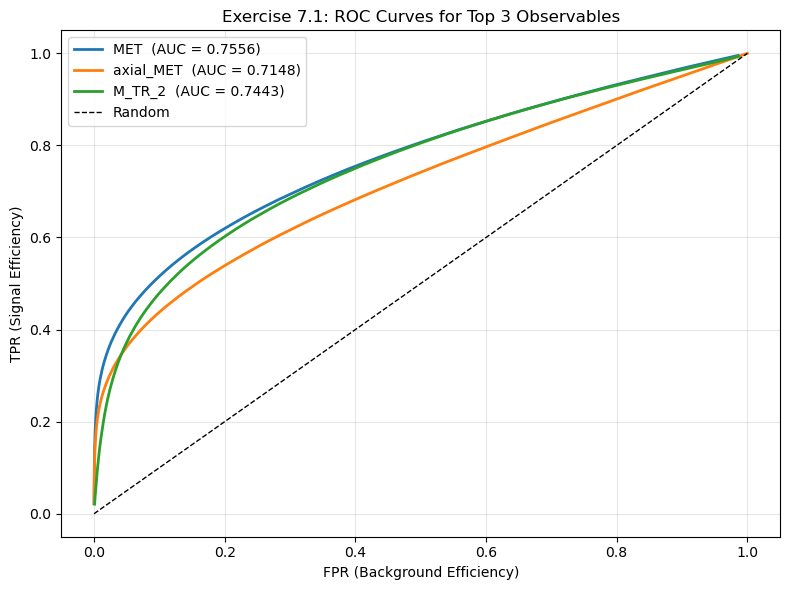

In [34]:
# 7.1

from sklearn.metrics import auc

top3 = [var for var, _, _, _ in results[:3]]

fig, ax = plt.subplots(figsize=(8, 6))

for var in top3:
    xc, tpr, fpr = efficiencies[var]
    roc_auc = auc(fpr, tpr)
    ax.plot(fpr, tpr, lw=2, label=f"{var}  (AUC = {roc_auc:.4f})")

ax.plot([0, 1], [0, 1], 'k--', lw=1, label='Random')
ax.set_xlabel('FPR (Background Efficiency)')
ax.set_ylabel('TPR (Signal Efficiency)')
ax.set_title('Exercise 7.1: ROC Curves for Top 3 Observables')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

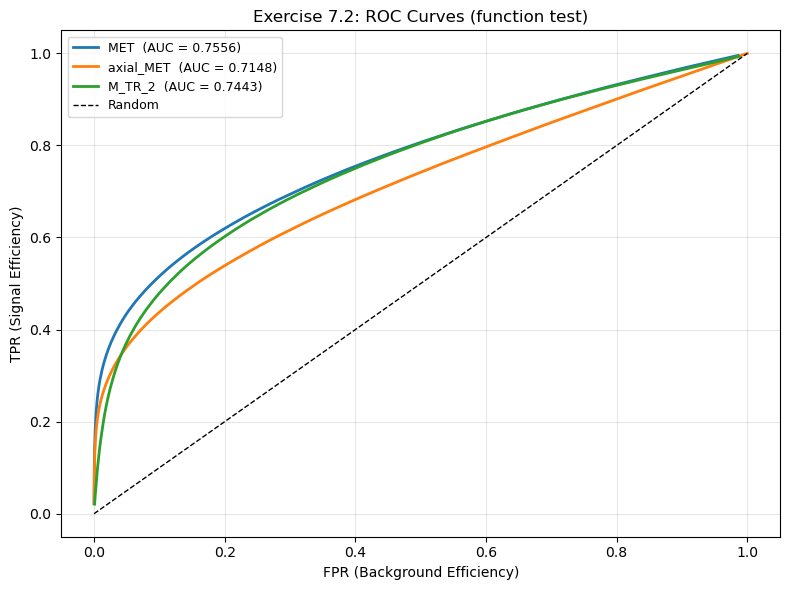

In [35]:
# 7.2

def plot_roc(var_list, efficiencies, title='ROC Curves', ax=None):
    """
    Plot ROC curves for a list of observables.
    
    Parameters
    ----------
    var_list    : list of observable names to plot
    efficiencies: dict of {var: (xc_array, tpr_array, fpr_array)}
    title       : plot title
    ax          : existing matplotlib Axes to draw on (creates new figure if None)
    """
    if ax is None:
        fig, ax = plt.subplots(figsize=(8, 6))

    for var in var_list:
        xc, tpr, fpr = efficiencies[var]
        roc_auc = auc(fpr, tpr)
        ax.plot(fpr, tpr, lw=2, label=f"{var}  (AUC = {roc_auc:.4f})")

    ax.plot([0, 1], [0, 1], 'k--', lw=1, label='Random')
    ax.set_xlabel('FPR (Background Efficiency)')
    ax.set_ylabel('TPR (Signal Efficiency)')
    ax.set_title(title)
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

# Quick test
plot_roc(top3, efficiencies, title='Exercise 7.2: ROC Curves (function test)')

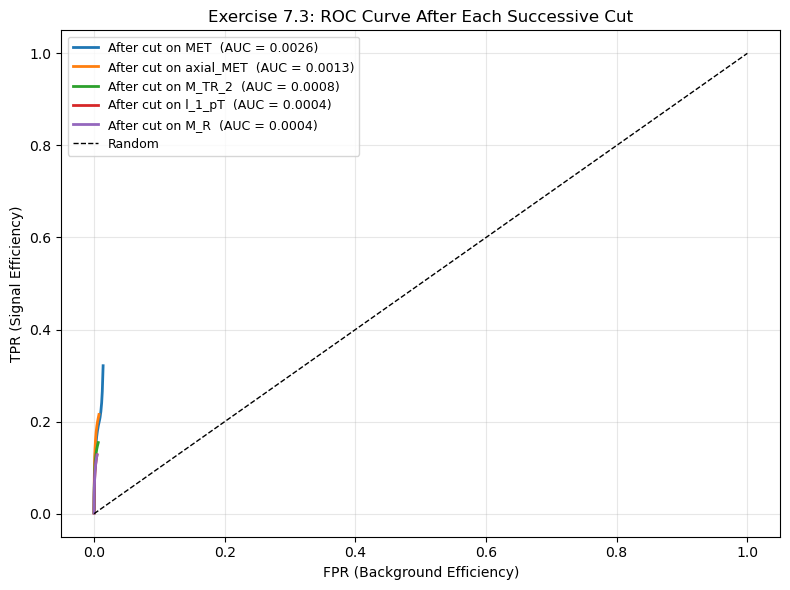

In [39]:
# 7.3

# Re-applying cuts one by one and compute ROC after each step
# We use the second variable in each pair as the "observable being evaluated"
# after successive cuts on the preceding ones

fig, ax = plt.subplots(figsize=(8, 6))

sig_mask = np.ones(len(signal),     dtype=bool)
bg_mask  = np.ones(len(background), dtype=bool)

for step, (var, xc_val) in enumerate(selected.items()):
    c = criteria[var]
    all_vals = np.concatenate([signal[var].values, background[var].values])
    mu = np.mean(all_vals)

    sig_mask &= passes_cut(signal[var].values,     c, xc_val, mu)
    bg_mask  &= passes_cut(background[var].values, c, xc_val, mu)

    # Compute ROC for the next variable using only surviving events
    remaining_vars = [v for v in selected if v != var]
    if not remaining_vars:
        break
    next_var = remaining_vars[0]

    sig_after = signal[next_var].values[sig_mask]
    bg_after  = background[next_var].values[bg_mask]
    all_after = np.concatenate([sig_after, bg_after])
    mu_next   = np.mean(all_after)
    c_next    = criteria[next_var]

    if c_next in (3, 4):
        xc_arr = np.linspace(0, np.percentile(np.abs(all_after - mu_next), 99), 200)
    else:
        xc_arr = np.linspace(np.percentile(all_after, 1), np.percentile(all_after, 99), 200)

    if c_next == 1:
        tpr_r = np.array([np.sum(sig_after > xc) / len(signal) for xc in xc_arr])
        fpr_r = np.array([np.sum(bg_after  > xc) / len(background) for xc in xc_arr])
    elif c_next == 2:
        tpr_r = np.array([np.sum(sig_after < xc) / len(signal) for xc in xc_arr])
        fpr_r = np.array([np.sum(bg_after  < xc) / len(background) for xc in xc_arr])
    elif c_next == 3:
        tpr_r = np.array([np.sum(np.abs(sig_after - mu_next) > xc) / len(signal) for xc in xc_arr])
        fpr_r = np.array([np.sum(np.abs(bg_after  - mu_next) > xc) / len(background) for xc in xc_arr])
    else:
        tpr_r = np.array([np.sum(np.abs(sig_after - mu_next) < xc) / len(signal) for xc in xc_arr])
        fpr_r = np.array([np.sum(np.abs(bg_after  - mu_next) < xc) / len(background) for xc in xc_arr])

    roc_auc = auc(fpr_r, tpr_r)
    ax.plot(fpr_r, tpr_r, lw=2,
            label=f"After cut on {var}  (AUC = {roc_auc:.4f})")

ax.plot([0, 1], [0, 1], 'k--', lw=1, label='Random')
ax.set_xlabel('FPR (Background Efficiency)')
ax.set_ylabel('TPR (Signal Efficiency)')
ax.set_title('Exercise 7.3: ROC Curve After Each Successive Cut')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

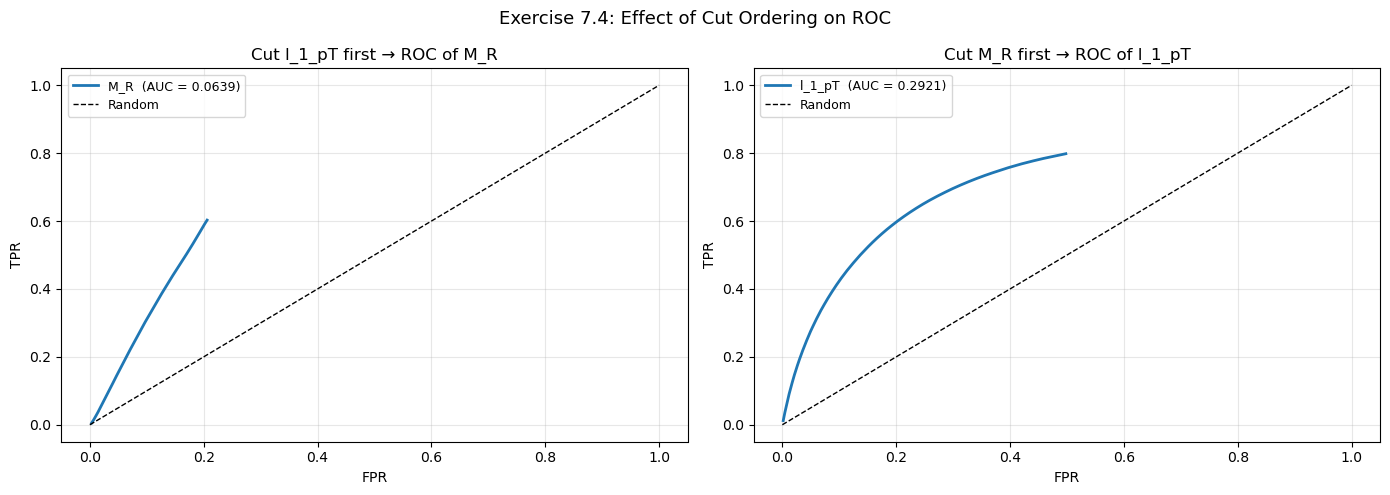

In [38]:
# 7.4

# Comparing ROC of var_b after cutting var_a first vs var_a after cutting var_b first

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (first, second) in zip(axes, [(var_a, var_b), (var_b, var_a)]):
    xc_first = selected[first]
    c_first  = criteria[first]
    all_vals = np.concatenate([signal[first].values, background[first].values])
    mu_first = np.mean(all_vals)

    sig_pass = passes_cut(signal[first].values,     c_first, xc_first, mu_first)
    bg_pass  = passes_cut(background[first].values, c_first, xc_first, mu_first)

    sig_after = signal[second].values[sig_pass]
    bg_after  = background[second].values[bg_pass]
    all_after = np.concatenate([sig_after, bg_after])
    mu_second = np.mean(all_after)
    c_second  = criteria[second]

    if c_second in (3, 4):
        xc_arr = np.linspace(0, np.percentile(np.abs(all_after - mu_second), 99), 200)
    else:
        xc_arr = np.linspace(np.percentile(all_after, 1), np.percentile(all_after, 99), 200)

    if c_second == 1:
        tpr2 = np.array([np.sum(sig_after > xc) / len(signal) for xc in xc_arr])
        fpr2 = np.array([np.sum(bg_after  > xc) / len(background) for xc in xc_arr])
    elif c_second == 2:
        tpr2 = np.array([np.sum(sig_after < xc) / len(signal) for xc in xc_arr])
        fpr2 = np.array([np.sum(bg_after  < xc) / len(background) for xc in xc_arr])
    elif c_second == 3:
        tpr2 = np.array([np.sum(np.abs(sig_after - mu_second) > xc) / len(signal) for xc in xc_arr])
        fpr2 = np.array([np.sum(np.abs(bg_after  - mu_second) > xc) / len(background) for xc in xc_arr])
    else:
        tpr2 = np.array([np.sum(np.abs(sig_after - mu_second) < xc) / len(signal) for xc in xc_arr])
        fpr2 = np.array([np.sum(np.abs(bg_after  - mu_second) < xc) / len(background) for xc in xc_arr])

    roc_auc = auc(fpr2, tpr2)
    ax.plot(fpr2, tpr2, lw=2, label=f"{second}  (AUC = {roc_auc:.4f})")
    ax.plot([0, 1], [0, 1], 'k--', lw=1, label='Random')
    ax.set_title(f"Cut {first} first → ROC of {second}")
    ax.set_xlabel('FPR')
    ax.set_ylabel('TPR')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

fig.suptitle('Exercise 7.4: Effect of Cut Ordering on ROC', fontsize=13)
plt.tight_layout()
plt.show()

In [40]:
# 8.1

obs = VarNames[1:]  # all observables except label

sig_vals = signal[obs].values
bg_vals  = background[obs].values

m1 = np.mean(bg_vals,  axis=0)  # background mean vector
m2 = np.mean(sig_vals, axis=0)  # signal mean vector

diff = (m2 - m1).reshape(-1, 1)
S_B  = diff @ diff.T

S_W  = np.zeros((len(obs), len(obs)))
for x in bg_vals:
    d = (x - m1).reshape(-1, 1)
    S_W += d @ d.T
for x in sig_vals:
    d = (x - m2).reshape(-1, 1)
    S_W += d @ d.T

print("S_B shape:", S_B.shape)
print("S_W shape:", S_W.shape)

S_B shape: (18, 18)
S_W shape: (18, 18)


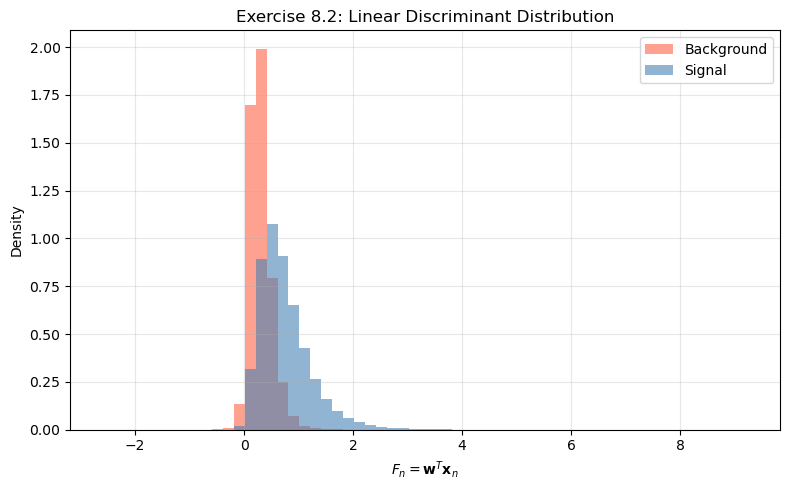

In [41]:
# 8.2

w = np.linalg.inv(S_W) @ (m2 - m1)
w = w / np.linalg.norm(w)  # normalize

F_sig = sig_vals @ w
F_bg  = bg_vals  @ w

bins = np.linspace(min(F_sig.min(), F_bg.min()),
                   max(F_sig.max(), F_bg.max()), 60)

plt.figure(figsize=(8, 5))
plt.hist(F_bg,  bins=bins, alpha=0.6, color='tomato',    density=True, label='Background')
plt.hist(F_sig, bins=bins, alpha=0.6, color='steelblue', density=True, label='Signal')
plt.xlabel(r'$F_n = \mathbf{w}^T \mathbf{x}_n$')
plt.ylabel('Density')
plt.title('Exercise 8.2: Linear Discriminant Distribution')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

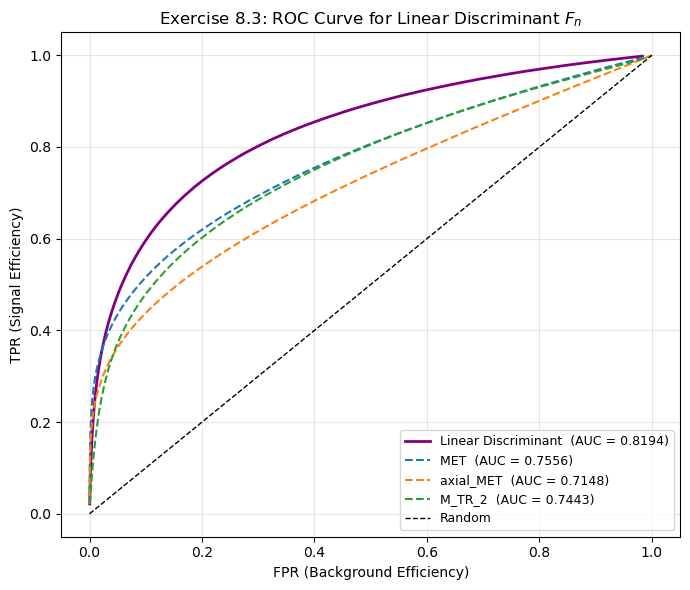

In [42]:
# 8.3

# Sweep threshold over F values and compute TPR/FPR
xc_arr = np.linspace(np.percentile(np.concatenate([F_sig, F_bg]), 1),
                     np.percentile(np.concatenate([F_sig, F_bg]), 99), 300)

tpr_ld = np.array([np.sum(F_sig > xc) / len(F_sig) for xc in xc_arr])
fpr_ld = np.array([np.sum(F_bg  > xc) / len(F_bg)  for xc in xc_arr])

roc_auc_ld = auc(fpr_ld, tpr_ld)

fig, ax = plt.subplots(figsize=(7, 6))
ax.plot(fpr_ld, tpr_ld, lw=2, color='purple',
        label=f'Linear Discriminant  (AUC = {roc_auc_ld:.4f})')

# Overlaying top 3 single-variable ROCs for comparison
for var in top3:
    _, tpr_v, fpr_v = efficiencies[var]
    ax.plot(fpr_v, tpr_v, lw=1.5, linestyle='--',
            label=f'{var}  (AUC = {auc(fpr_v, tpr_v):.4f})')

ax.plot([0, 1], [0, 1], 'k--', lw=1, label='Random')
ax.set_xlabel('FPR (Background Efficiency)')
ax.set_ylabel('TPR (Signal Efficiency)')
ax.set_title('Exercise 8.3: ROC Curve for Linear Discriminant $F_n$')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# part until overlaying generated and explained by Claude

In [43]:
# 8.4

print("Maximum significance achievable with Linear Discriminant:\n")
print(f"{'Scenario':<25} {'Max σ':>10}  {'Best threshold':>15}")
print("-" * 55)

for N_S, N_B in scenarios:
    sig_vals_arr = significance(tpr_ld, fpr_ld, N_S, N_B)
    idx_max = np.argmax(sig_vals_arr)
    print(f"N_S={N_S:<6}, N_B={N_B:<8}  {sig_vals_arr[idx_max]:>10.4f}  {xc_arr[idx_max]:>15.4f}")

Maximum significance achievable with Linear Discriminant:

Scenario                       Max σ   Best threshold
-------------------------------------------------------
N_S=10    , N_B=100           1.5271           0.6759
N_S=100   , N_B=1000          4.8292           0.6759
N_S=1000  , N_B=10000        15.2714           0.6759
N_S=10000 , N_B=100000       48.2924           0.6759
